# Import

In [1]:
import matplotlib.patheffects as mpe
import matplotlib.pyplot as plt
import numpy as np
import pysam
import re
import pandas as pd
from matplotlib.ticker import FuncFormatter
plt.rcParams.update({'font.size': 20})
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches
import matplotlib.ticker as ticker


# Function

In [2]:
def plot(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(40,15)
    plt.rcParams.update({'font.size': 30})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)
    y2_values = [float(val[1]) for val in loc1.values()]  # Second part of the stack (converted to int)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='methylated', color='blue',align='center',width=5)
    plt.bar(x, y2_values, bottom=y1_values, label='unmethylated', color='red',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=30)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=30)
    plt.ylabel(Ylabel, fontsize=30)
    plt.title(title, fontsize=30)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [3]:
 def Intron6t8cov(inFile):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

    seqLoc2 = {}

    count = 1175534

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1175535 and int(cols[1])<=1181032 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[4]]
    file.close()  
    print(str(inFile))
    plotCov(seqLoc2,"Positions","Coverage", "Coverage of CpG in Intron 6 to 8", "Percentage of CpG Methylation in Intron 6 to 8")

In [4]:
def Intron6t8meth(inFile):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

    seqLoc2 = {}

    count = 1175534

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1175535 and int(cols[1])<=1181032 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage of CpG Methylation in Intron 6 to 8", "Percentage of CpG Methylation in Intron 6 to 8")

In [5]:
 def TAPAScov(inFile):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

    seqLoc2 = {}

    count = 1196005

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1196006 and int(cols[1])<=1205278 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[4]]
    file.close()  
    print(str(inFile))
    plotCov(seqLoc2,"Positions","Coverage", "Coverage of CpG Across hTAPAS to Intron 2", "Percentage CpG Methylation Across hTAPAS to Intron 2")

In [6]:
 def TAPASmeth(inFile):
    file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa","r")

    seqLoc2 = {}

    count = 1196005

    for line in file:
        a = list(line)
        for i in a:
            count +=1
            seqLoc2[count]=[0,0]
    file.close()   

    file = open("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/"+inFile,"r")
    for line in file:
        cols = line.split("\t")
        if cols[0]=="NC_060929.1" and int(cols[1])>=1196006 and int(cols[1])<=1205278 and cols[3]=="m":
            for k,v in seqLoc2.items():
                if int(cols[1])==k:
                    seqLoc2[k]=[cols[10],100-float(cols[10])]
    file.close()  
    print(str(inFile))
    plot(seqLoc2,"Positions","Percentage", "Percentage CpG Methylation Across hTAPAS to Intron 2", "Percentage CpG Methylation Across hTAPAS to Intron 2")

In [7]:
def plotCov(loc1,Xlabel,Ylabel,title,out):
    fig = plt.gcf()
    fig.set_size_inches(40,15)
    plt.rcParams.update({'font.size': 30})
    outline=mpe.withStroke(linewidth=8, foreground='black')

    # Extract keys as x labels and values as separate parts of the stack
    x_labels = list(loc1.keys())
    y1_values = [float(val[0]) for val in loc1.values()]  # First part of the stack (converted to float)

    # Set positions for x-axis
    x = np.arange(len(x_labels))

    # Create the stacked bar plot
    plt.bar(x, y1_values, label='coverage', color='brown',align='center',width=5)

    # Customize the plot
    tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
    tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

    plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=30)  # Rotate x labels for better visibility
    plt.xlabel(Xlabel, fontsize=30)
    plt.ylabel(Ylabel, fontsize=30)
    plt.title(title, fontsize=30)
    plt.legend(bbox_to_anchor=(0, -0.2), loc='upper left')
    plt.margins(0)
    

    # Add a border around the plot
    plt.gca().spines['top'].set_linewidth(1.5)
    plt.gca().spines['right'].set_linewidth(1.5)
    plt.gca().spines['bottom'].set_linewidth(1.5)
    plt.gca().spines['left'].set_linewidth(1.5)
    plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/"+out+".pdf", format="pdf", bbox_inches="tight")

    # Show plot
    plt.tight_layout()
    plt.show()

In [10]:

# Function to parse SAM file and filter primary alignments
def parse_sam(sam_file):
    primary_alignments = []
    chromosomes = set()  # Set to store unique chromosome names
    
    with open(sam_file, 'r') as file:
        for line in file:
            if line.startswith('@'):
                continue  # Skip header lines
            fields = line.strip().split('\t')
            flag = int(fields[1])
            if (flag & 0x100) == 0:  # Primary alignment
                chrom = fields[2]
                pos = int(fields[3])
                primary_alignments.append((chrom, pos))
                chromosomes.add(chrom)  # Add chromosome to set
    
    return pd.DataFrame(primary_alignments, columns=['chr', 'position']), chromosomes

# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000

# Function to calculate read density in bins
def calculate_read_density(primary_alignments, bin_size, chromosomes):
    density_data = []
    for chrom in chromosomes:
        chrom_reads = primary_alignments[primary_alignments['chr'] == chrom]
        max_pos = chrom_reads['position'].max() if not chrom_reads.empty else 0
        bins = np.arange(0, max_pos + bin_size, bin_size)
        bin_counts, _ = np.histogram(chrom_reads['position'], bins=bins)
        density_data.extend([(chrom, start, start + bin_size, count) for start, count in zip(bins[:-1], bin_counts)])
    return pd.DataFrame(density_data, columns=['chr', 'start', 'end', 'count'])

# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)

# Plotting function for karyotype with density
def plot_karyotype_with_density(read_density, chromosomes):
    fig, ax = plt.subplots(figsize=(12, 8))
    y_position = 0

    # Iterate over each chromosome to plot read density
    for chrom in chromosomes:
        chrom_density = read_density[read_density['chr'] == chrom]
        
        max_pos = chrom_density['end'].max() if not chrom_density.empty else 0
        chrom_width = 0.6
        
        # Overlay density as a heatmap along the chromosome
        max_density = read_density['count'].max()  # Normalize based on maximum density
        for _, row in chrom_density.iterrows():
            density = row['count']
            intensity = density / max_density  # Normalize density to [0, 1]
            color = plt.cm.Reds(intensity)  # Use Reds colormap for heatmap effect
            rect = patches.Rectangle((y_position - chrom_width / 2, row['start']), chrom_width, row['end'] - row['start'],
                                     linewidth=0, edgecolor='none', facecolor=color)
            ax.add_patch(rect)

        # Label the chromosome
        ax.text(y_position, max_pos + 5e6, chrom, ha='center', va='bottom', fontsize=10)
        y_position += 1

    # Set the limits and labels
    ax.set_ylim(0, max(read_density['end']))
    ax.set_xlim(-1, y_position)
    ax.set_xlabel("Chromosomes")
    ax.set_ylabel("Position on Chromosome")
    ax.set_title("Read Density on Chromosomes")

    plt.colorbar(plt.cm.ScalarMappable(cmap='Reds'), ax=ax, orientation='horizontal', label='Read Density')
    plt.show()


# Off Targets 

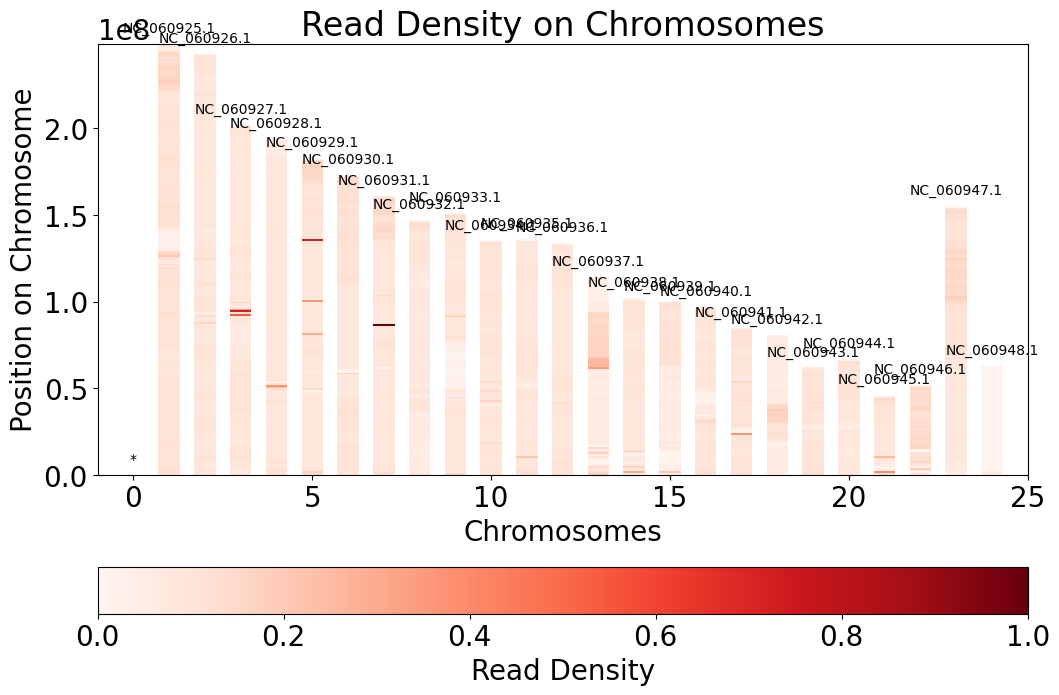

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
sam_file = "/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.sam"

# Function to parse SAM file and filter primary alignments
def parse_sam(sam_file):
    primary_alignments = []
    chromosomes = set()  # Set to store unique chromosome names
    
    with open(sam_file, 'r') as file:
        for line in file:
            if line.startswith('@'):
                continue  # Skip header lines
            fields = line.strip().split('\t')
            flag = int(fields[1])
            if (flag & 0x100) == 0:  # Primary alignment
                chrom = fields[2]
                pos = int(fields[3])
                primary_alignments.append((chrom, pos))
                chromosomes.add(chrom)  # Add chromosome to set
    
    return pd.DataFrame(primary_alignments, columns=['chr', 'position']), chromosomes

# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000

# Function to calculate read density in bins
def calculate_read_density(primary_alignments, bin_size, chromosomes):
    density_data = []
    for chrom in chromosomes:
        chrom_reads = primary_alignments[primary_alignments['chr'] == chrom]
        max_pos = chrom_reads['position'].max() if not chrom_reads.empty else 0
        bins = np.arange(0, max_pos + bin_size, bin_size)
        bin_counts, _ = np.histogram(chrom_reads['position'], bins=bins)
        density_data.extend([(chrom, start, start + bin_size, count) for start, count in zip(bins[:-1], bin_counts)])
    return pd.DataFrame(density_data, columns=['chr', 'start', 'end', 'count'])

# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)

# Plotting function for karyotype with density
def plot_karyotype_with_density(read_density, chromosomes):
    fig, ax = plt.subplots(figsize=(12, 8))
    y_position = 0

    # Iterate over each chromosome to plot read density
    for chrom in chromosomes:
        chrom_density = read_density[read_density['chr'] == chrom]
        
        max_pos = chrom_density['end'].max() if not chrom_density.empty else 0
        chrom_width = 0.6
        
        # Overlay density as a heatmap along the chromosome
        max_density = read_density['count'].max()  # Normalize based on maximum density
        for _, row in chrom_density.iterrows():
            density = row['count']
            intensity = density / max_density  # Normalize density to [0, 1]
            color = plt.cm.Reds(intensity)  # Use Reds colormap for heatmap effect
            rect = patches.Rectangle((y_position - chrom_width / 2, row['start']), chrom_width, row['end'] - row['start'],
                                     linewidth=0, edgecolor='none', facecolor=color)
            ax.add_patch(rect)

        # Label the chromosome
        ax.text(y_position, max_pos + 5e6, chrom, ha='center', va='bottom', fontsize=10)
        y_position += 1

    # Set the limits and labels
    ax.set_ylim(0, max(read_density['end']))
    ax.set_xlim(-1, y_position)
    ax.set_xlabel("Chromosomes")
    ax.set_ylabel("Position on Chromosome")
    ax.set_title("Read Density on Chromosomes")

    plt.colorbar(plt.cm.ScalarMappable(cmap='Reds'), ax=ax, orientation='horizontal', label='Read Density')
    plt.show()

# Plot the karyotype with read density
plot_karyotype_with_density(read_density, chromosomes)

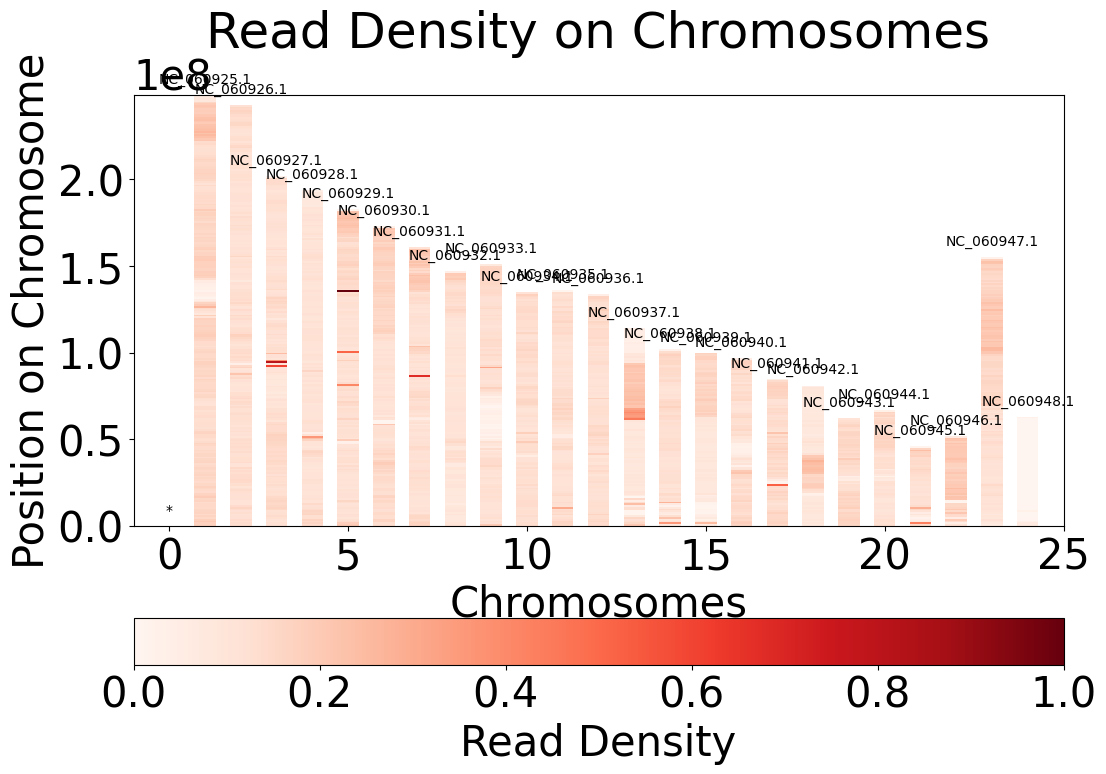

In [47]:
# File paths
sam_file = "/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.sam"
# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000
# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)
# Plot the karyotype with read density
plot_karyotype_with_density(read_density, chromosomes)

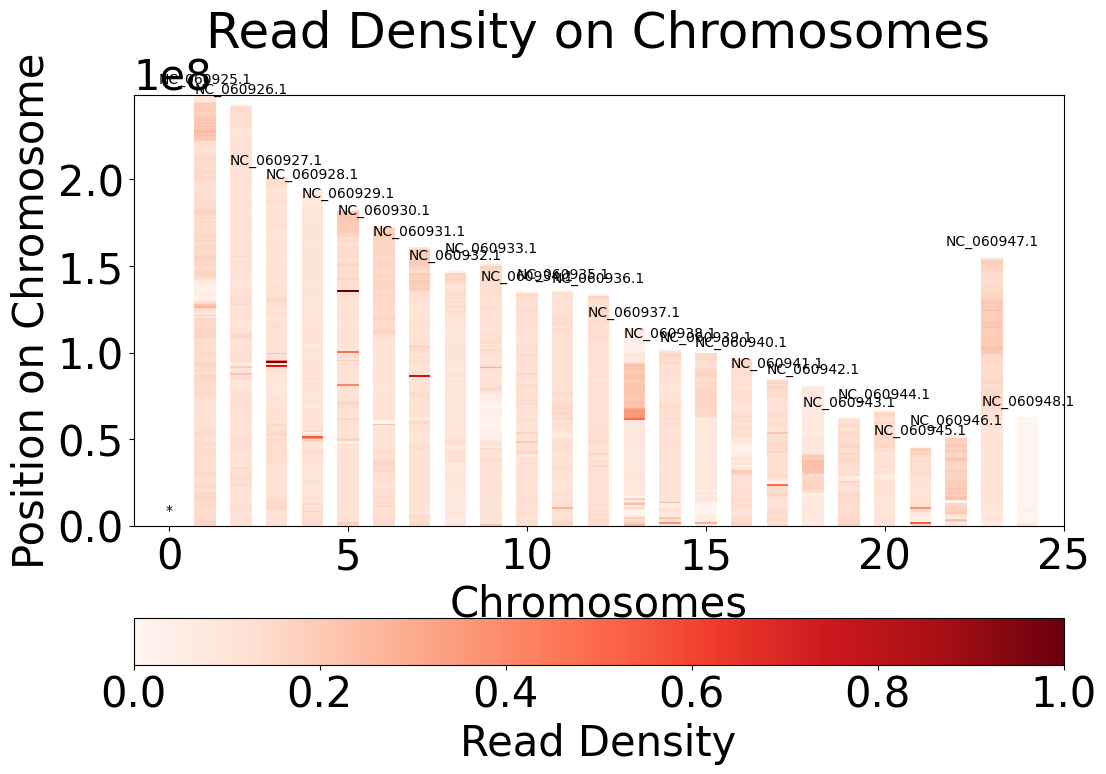

In [48]:
# File paths
sam_file = "/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.sam"
# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000
# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)
# Plot the karyotype with read density
plot_karyotype_with_density(read_density, chromosomes)

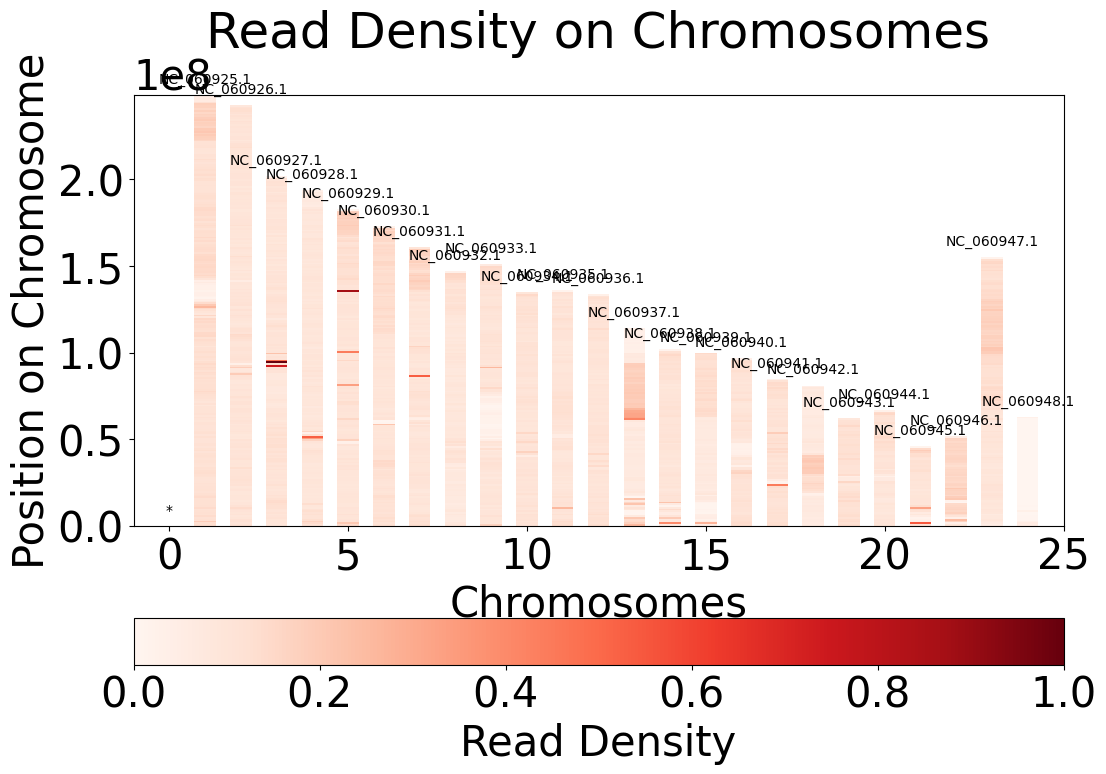

In [49]:
# File paths
sam_file = "/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.sam"
# Load SAM data and get unique chromosomes
primary_alignments, chromosomes = parse_sam(sam_file)

# Chromosome order for plotting (adapted based on the SAM file)
chromosomes = sorted(chromosomes)  # Sort chromosomes alphabetically

# Set bin size for density calculation (1 Mb bins)
bin_size = 1_000_000
# Calculate read density
read_density = calculate_read_density(primary_alignments, bin_size, chromosomes)
# Plot the karyotype with read density
plot_karyotype_with_density(read_density, chromosomes)

# Intron 6 to 8

## Coverage

In [35]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1175535-1181032 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1175535-1181032 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1175535-1181032 | wc -l; done

HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam
Average depth: 33.6304
Standard deviation: 2.91011
91
59


In [9]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1175535-1181032 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1175535-1181032 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1175535-1181032 | wc -l; done

6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam
Average depth: 6.78538
Standard deviation: 0.977441
20
13
6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam
Average depth: 13.3507
Standard deviation: 1.33467
28
23
6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam
Average depth: 6.02292
Standard deviation: 0.798679
21
11
6625ff67fb7d802182a83888398d8e73dbfd09d5_unclassified.bam.aligned.bam.sorted.bam
Average depth: 7.47144
Standard deviation: 0.934176
22
12


HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


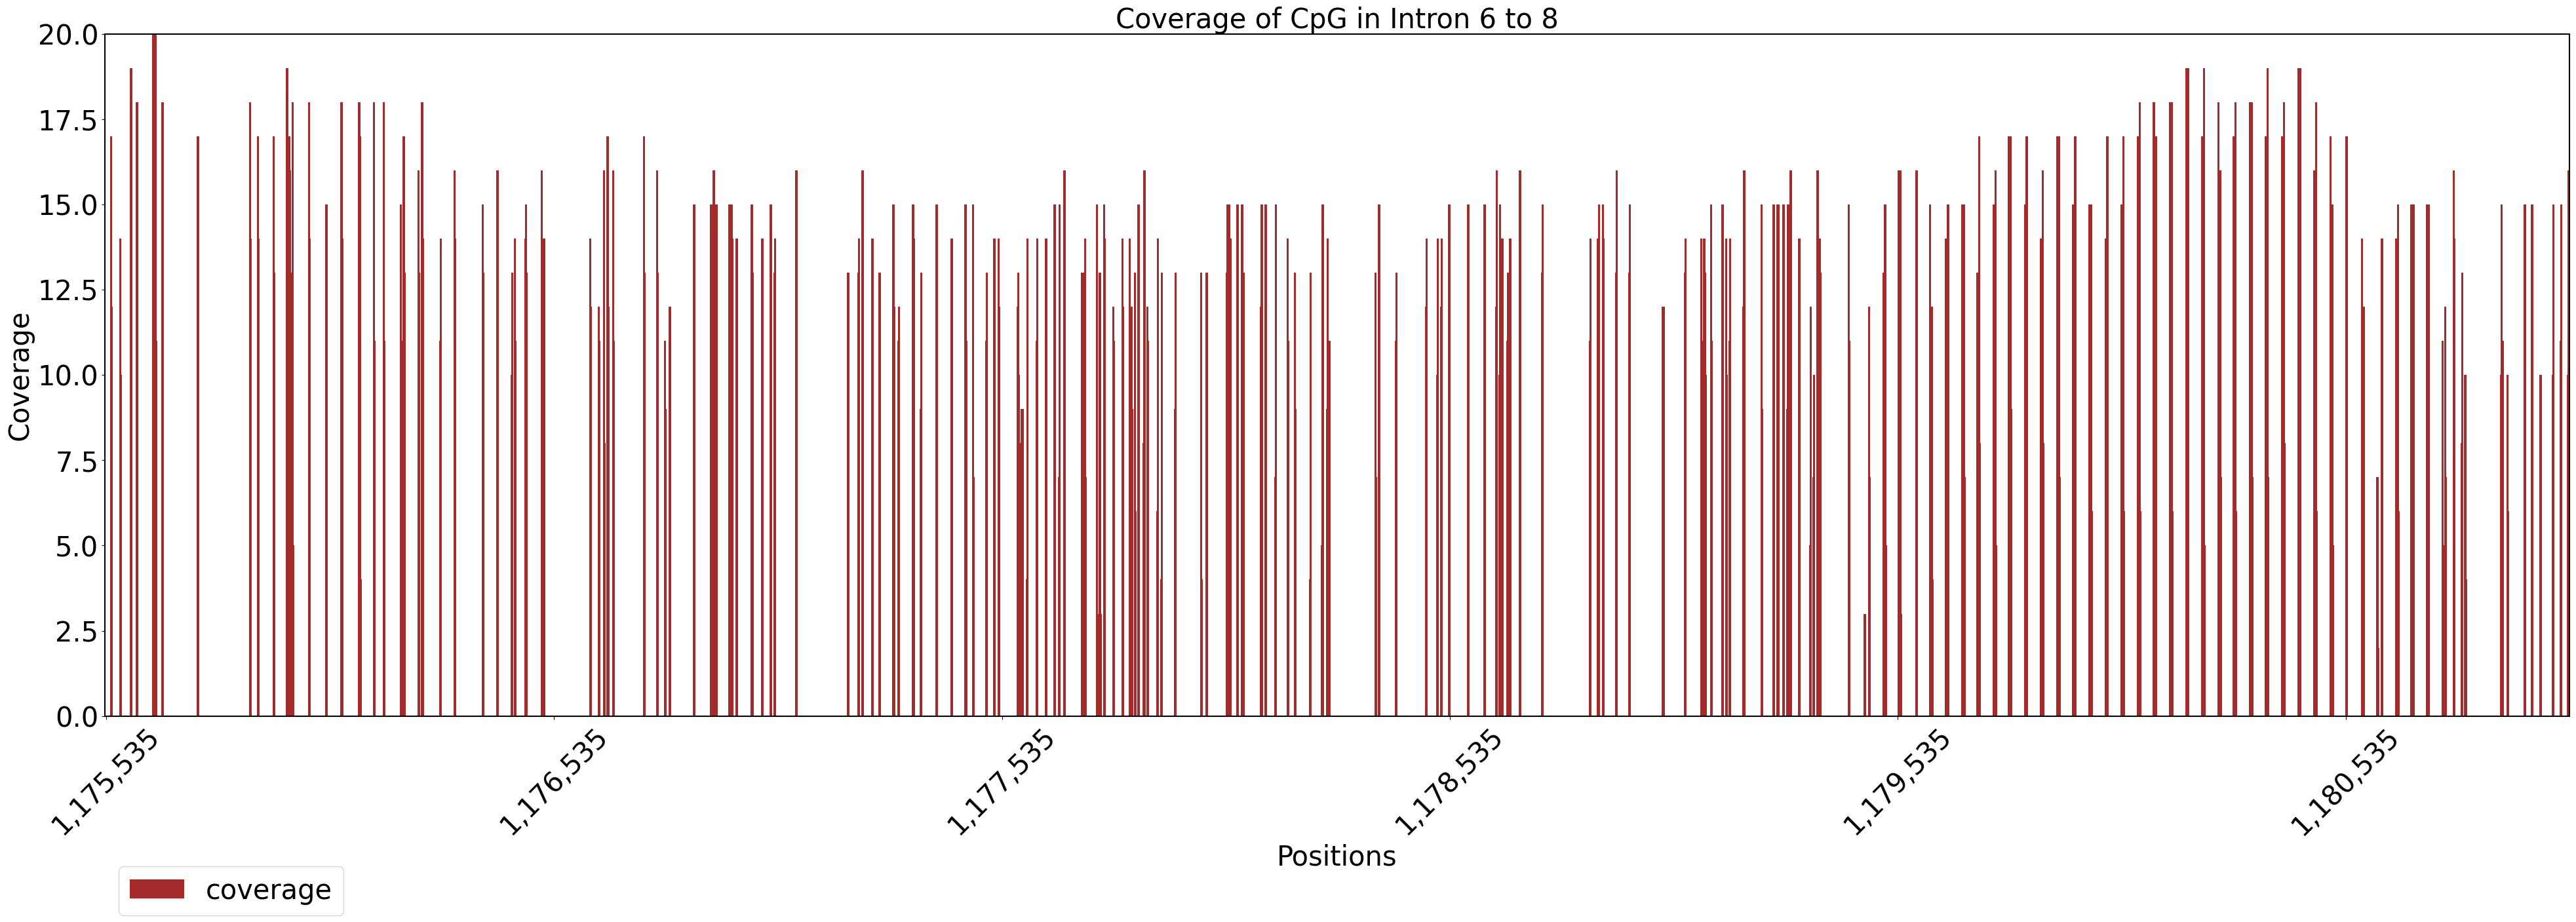

In [51]:
Intron6t8cov("HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed")

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.bed


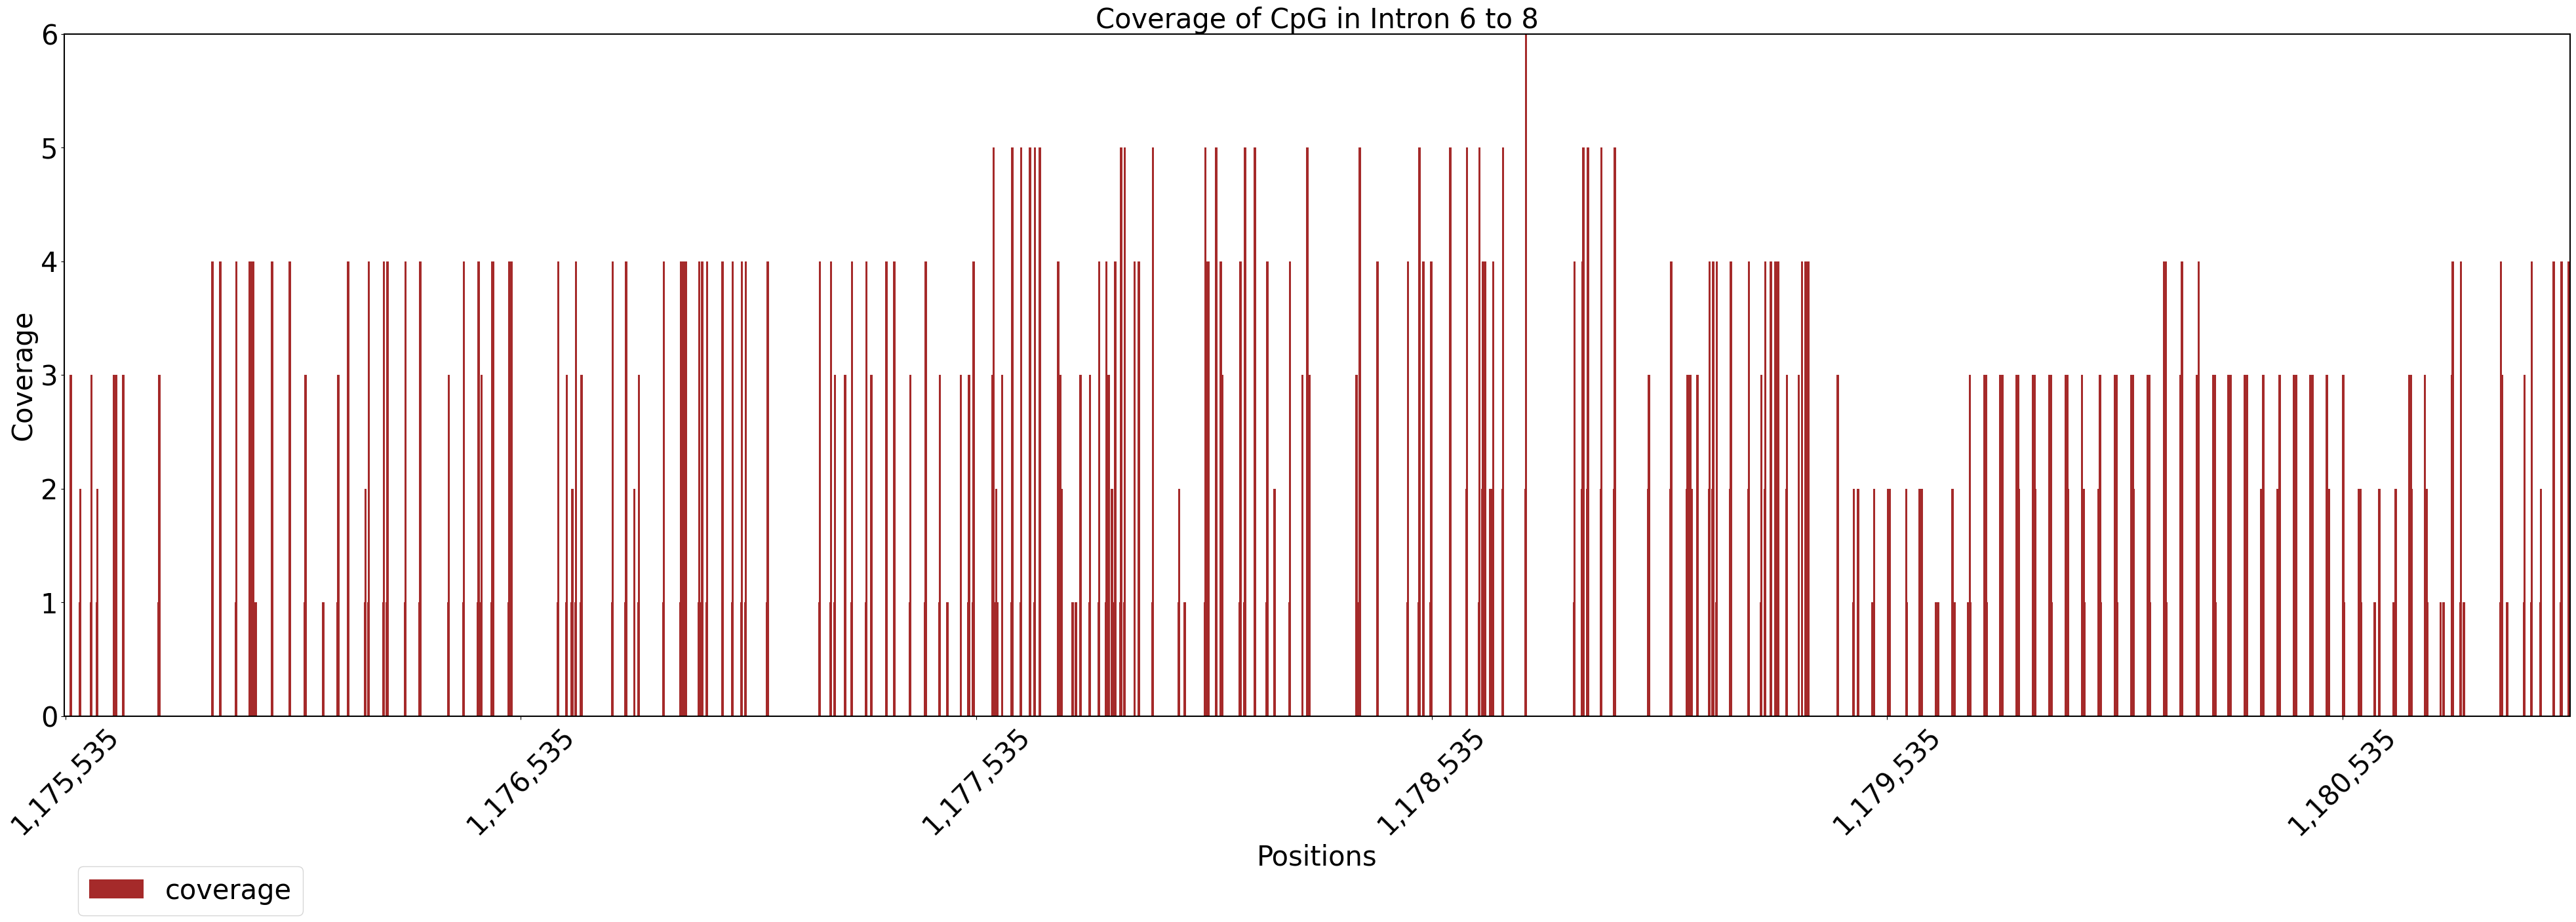

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


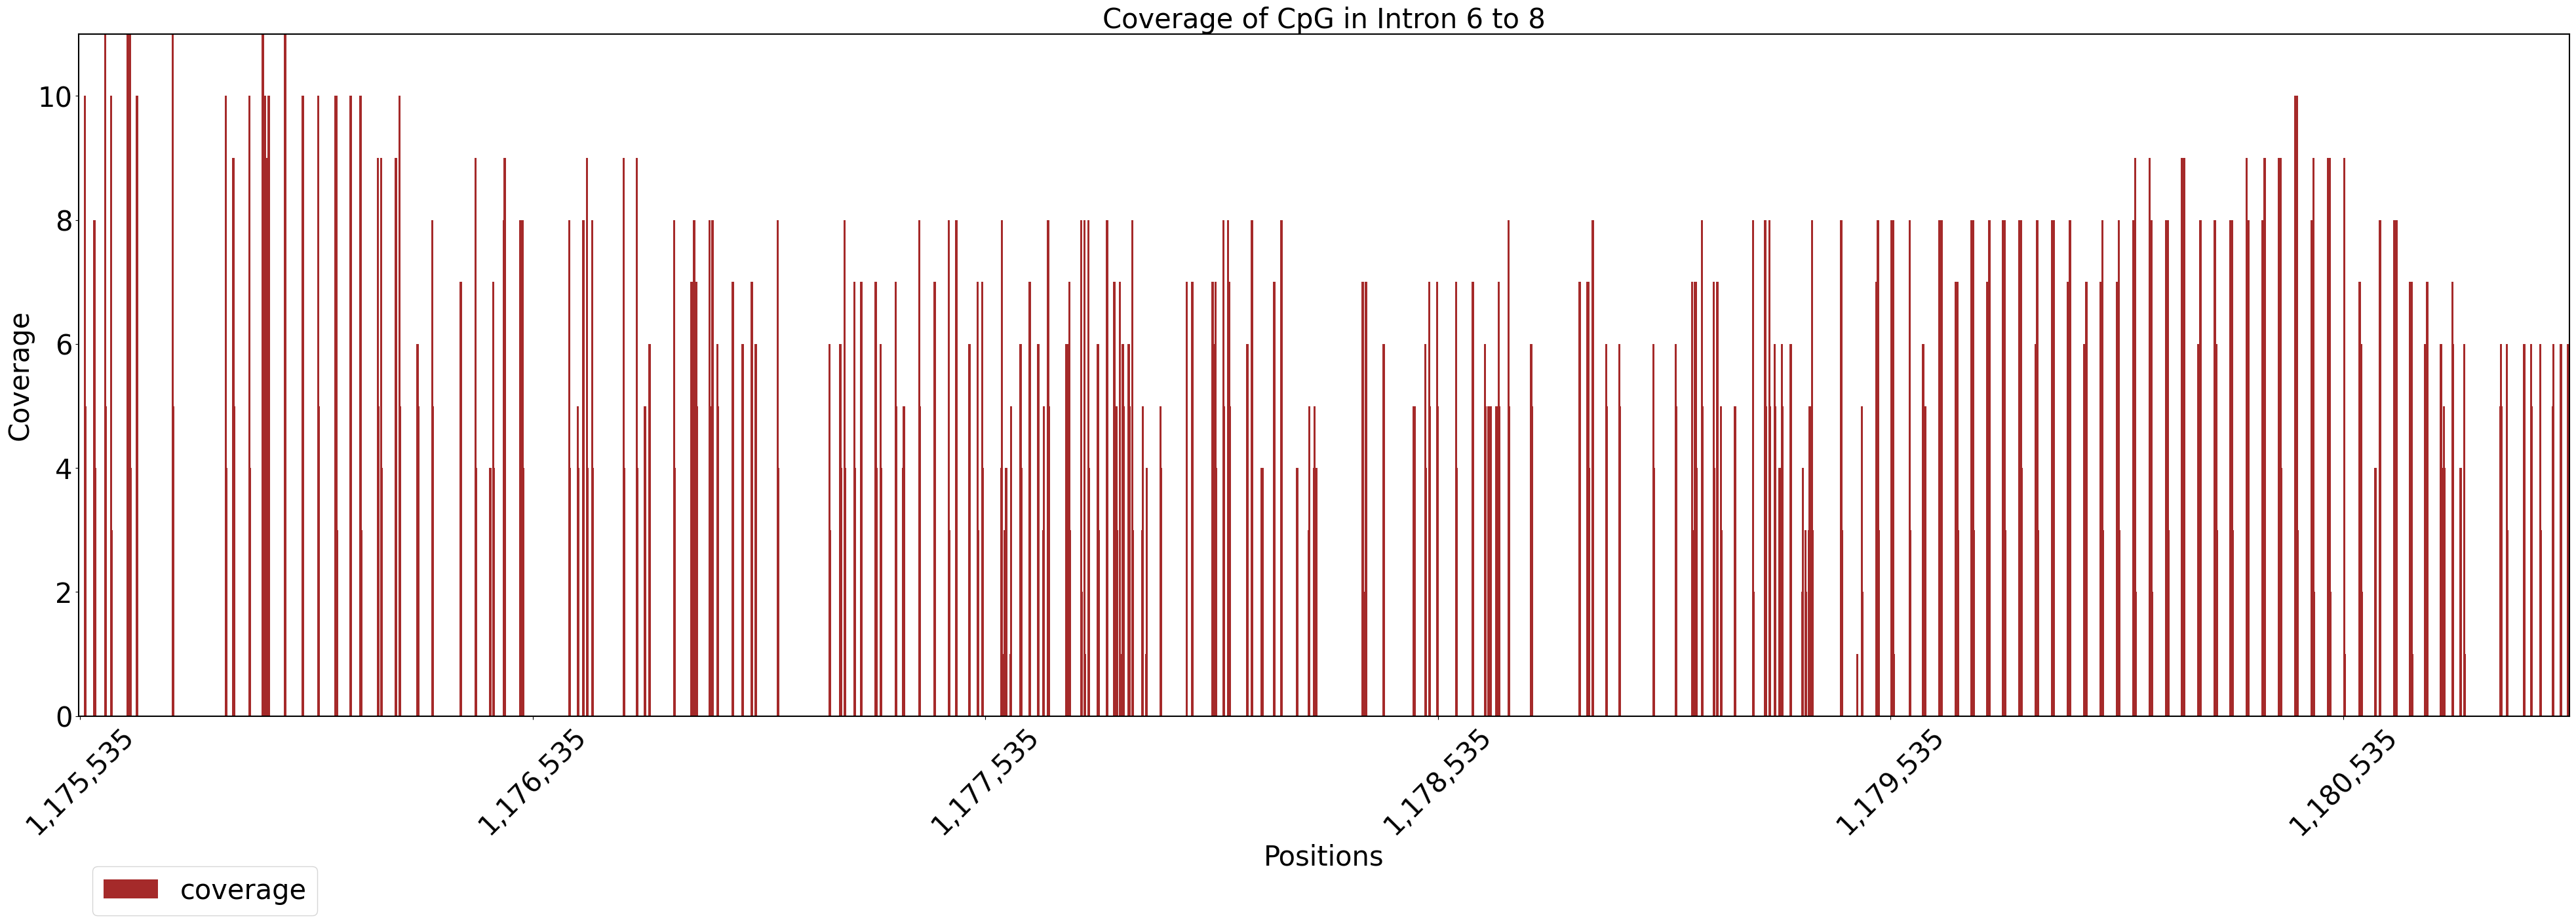

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.bed


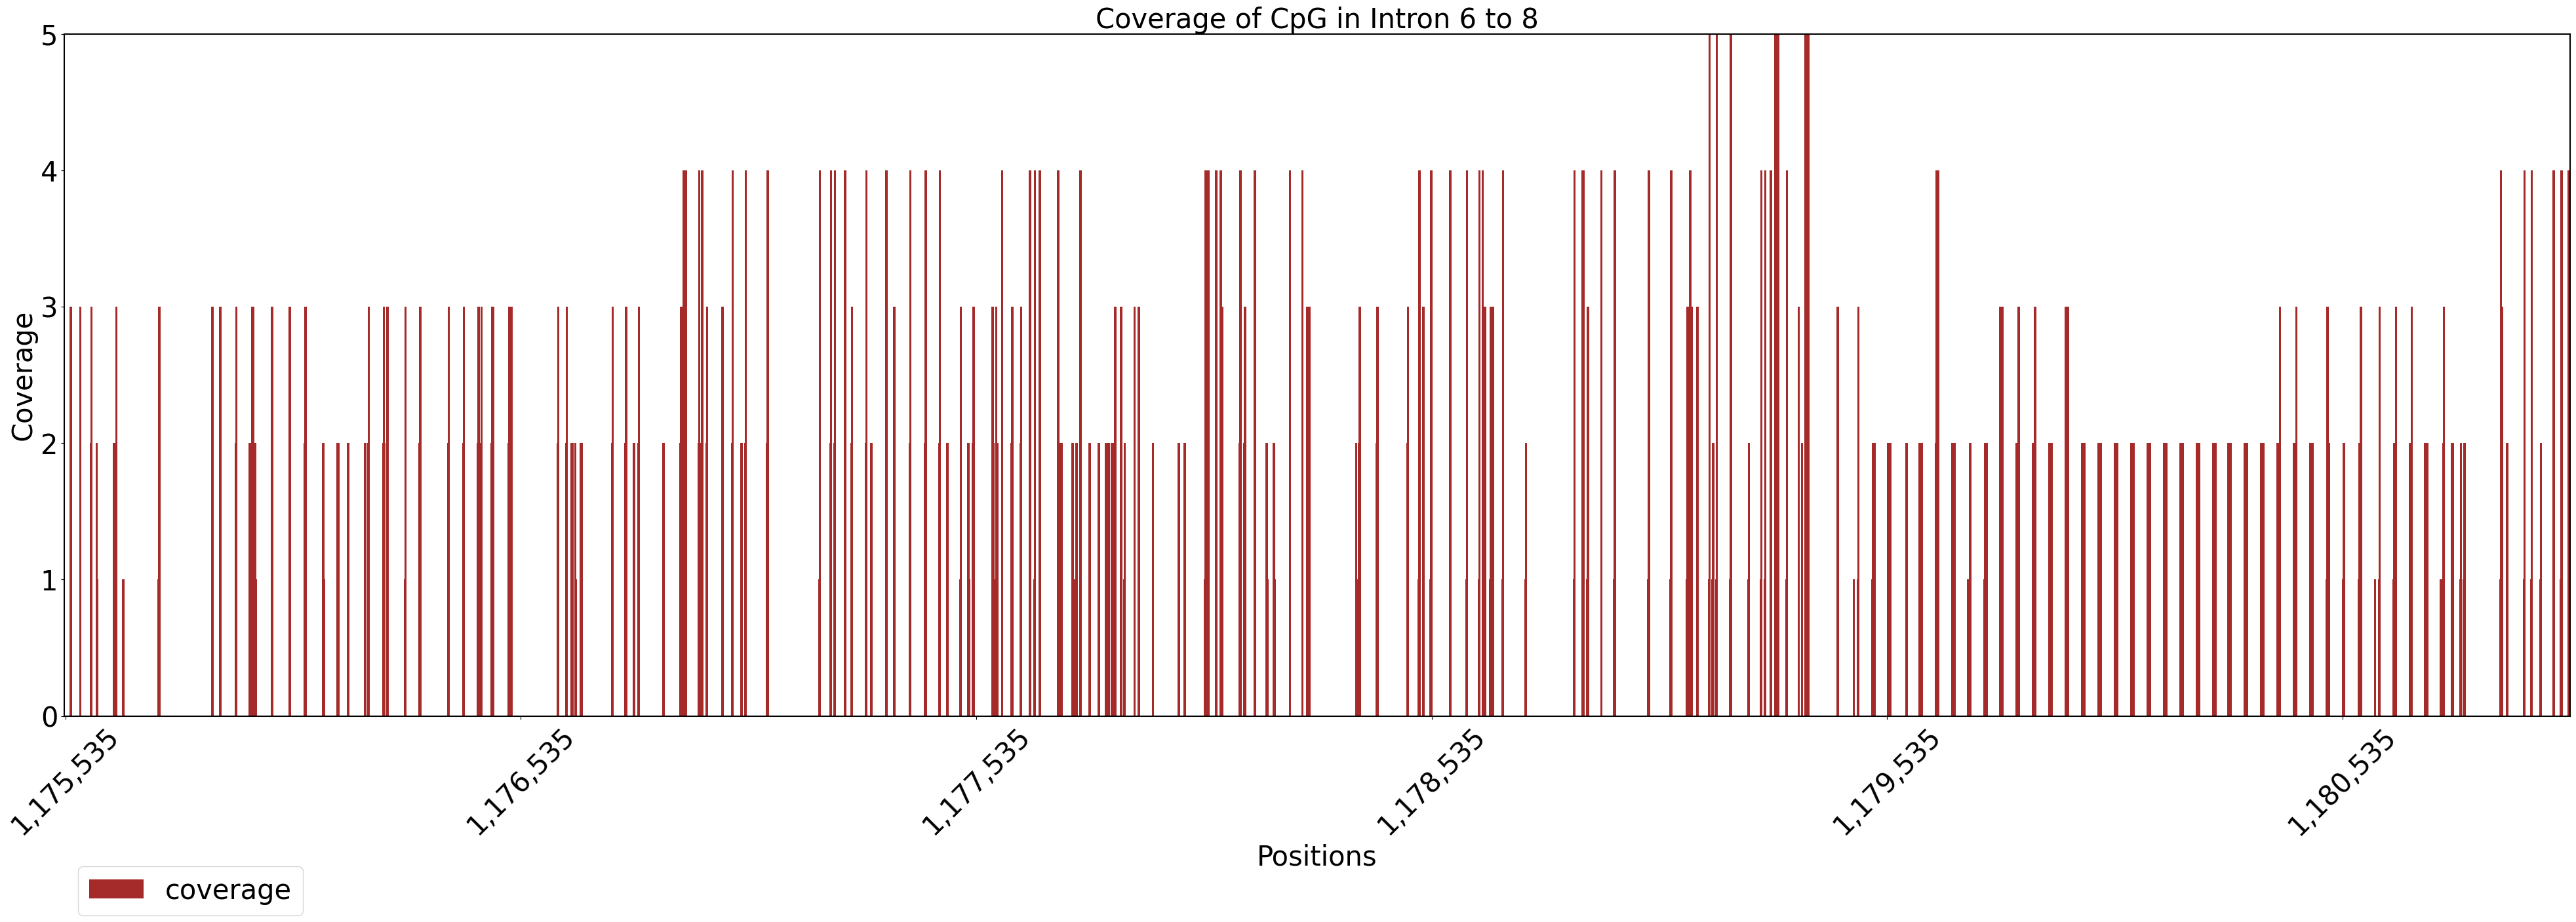

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_unclassified.bam.aligned.bam.sorted.bam.bed


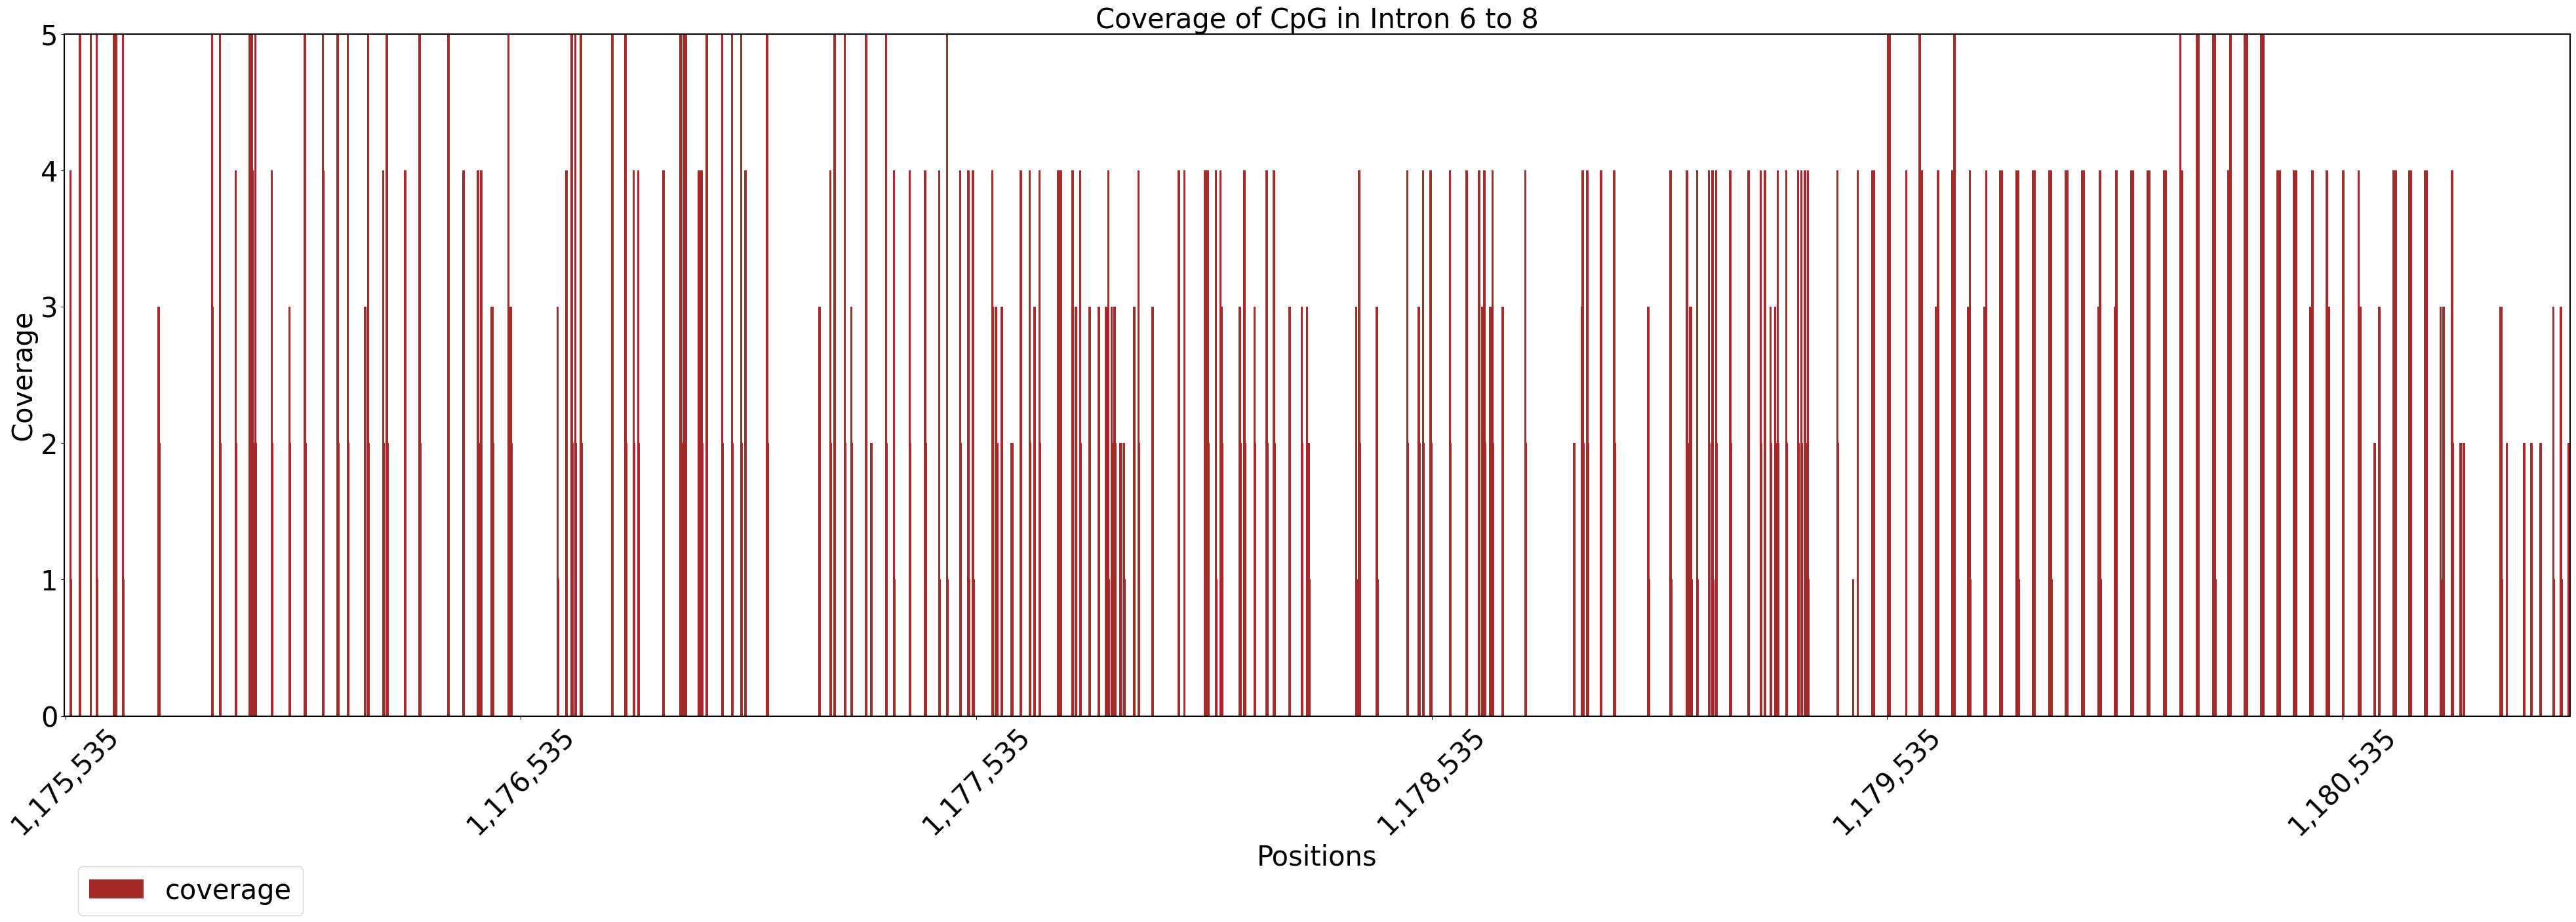

In [28]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    Intron6t8cov("DORADO_DEMUX/"+f)

## Methylation

HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


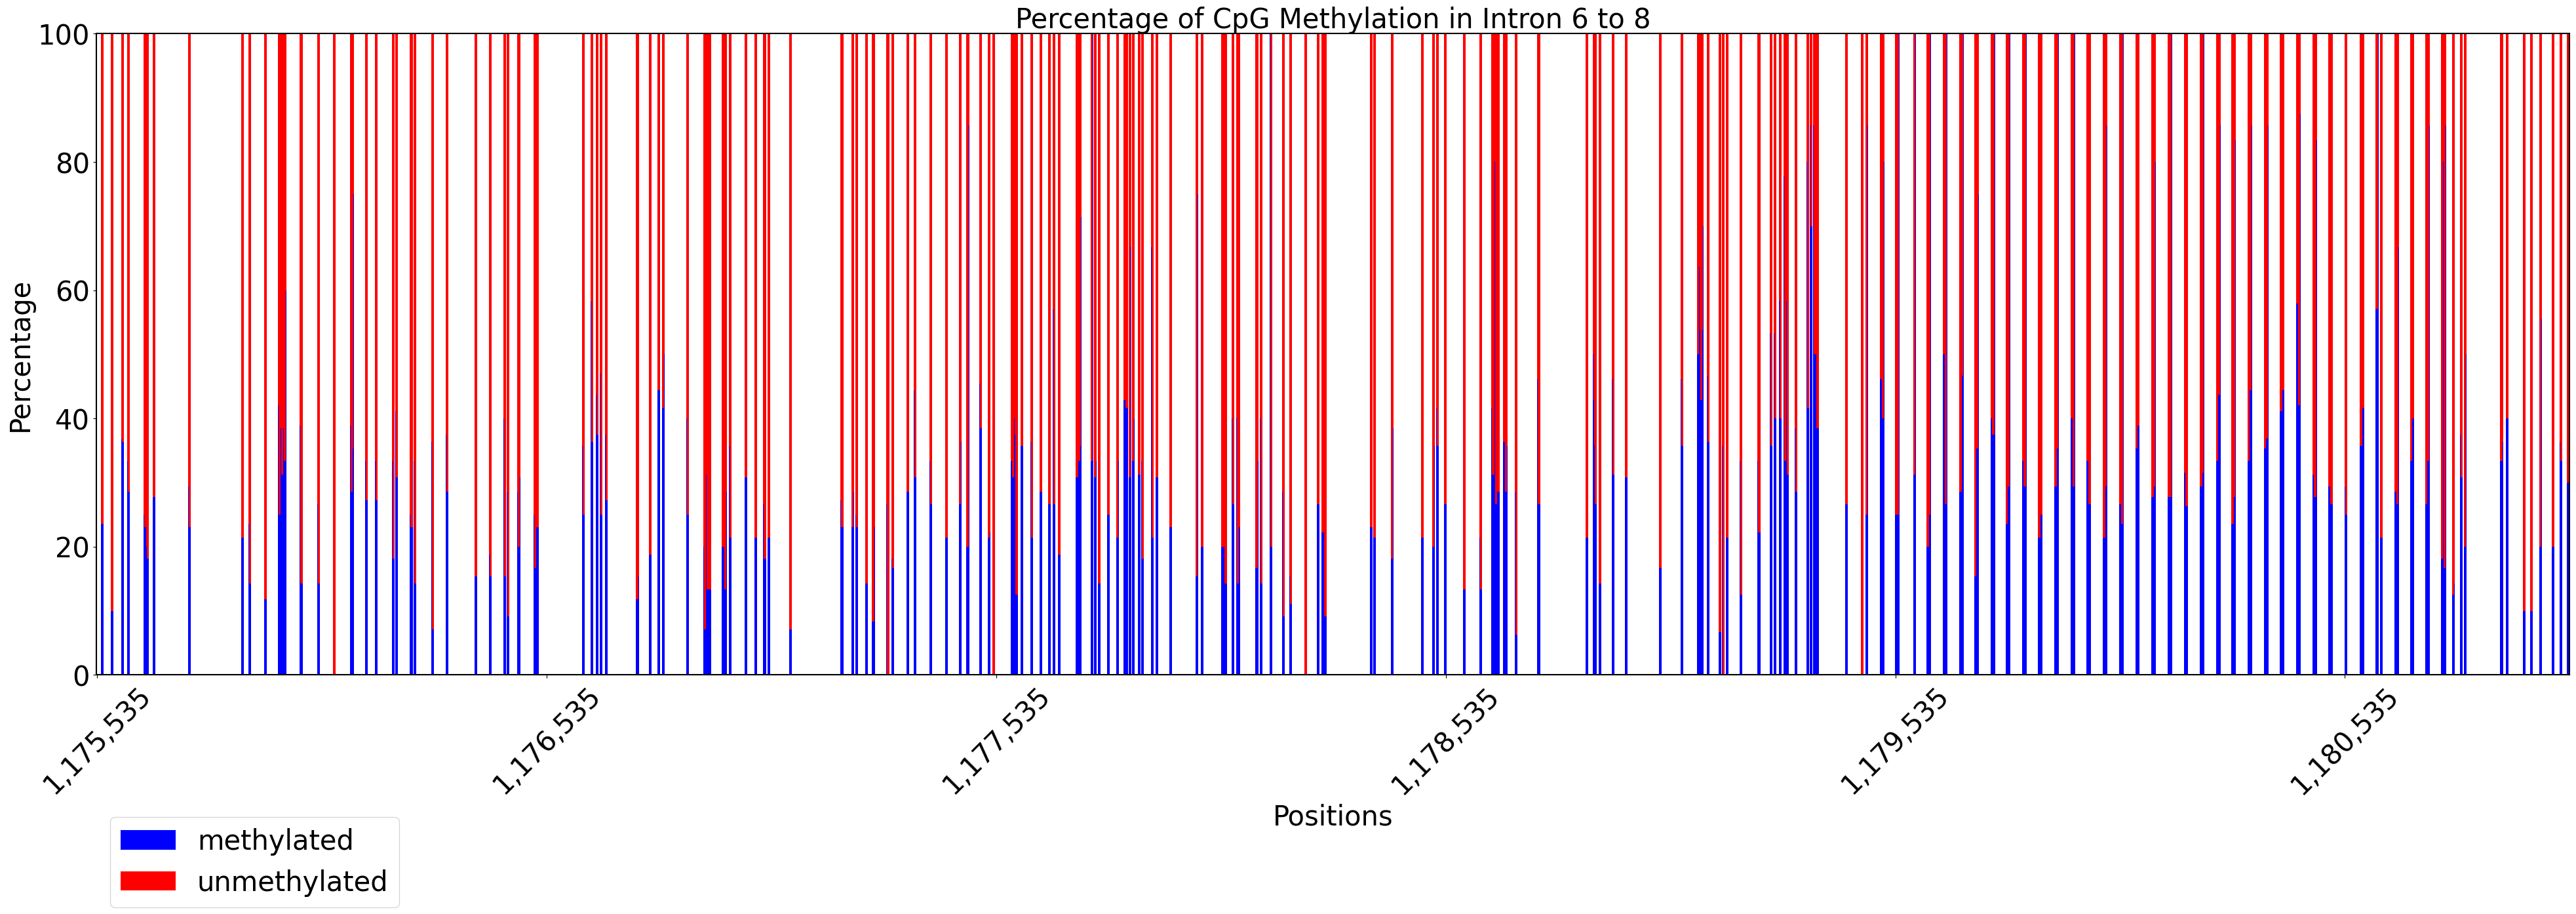

In [52]:
Intron6t8meth("HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed")

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.bed


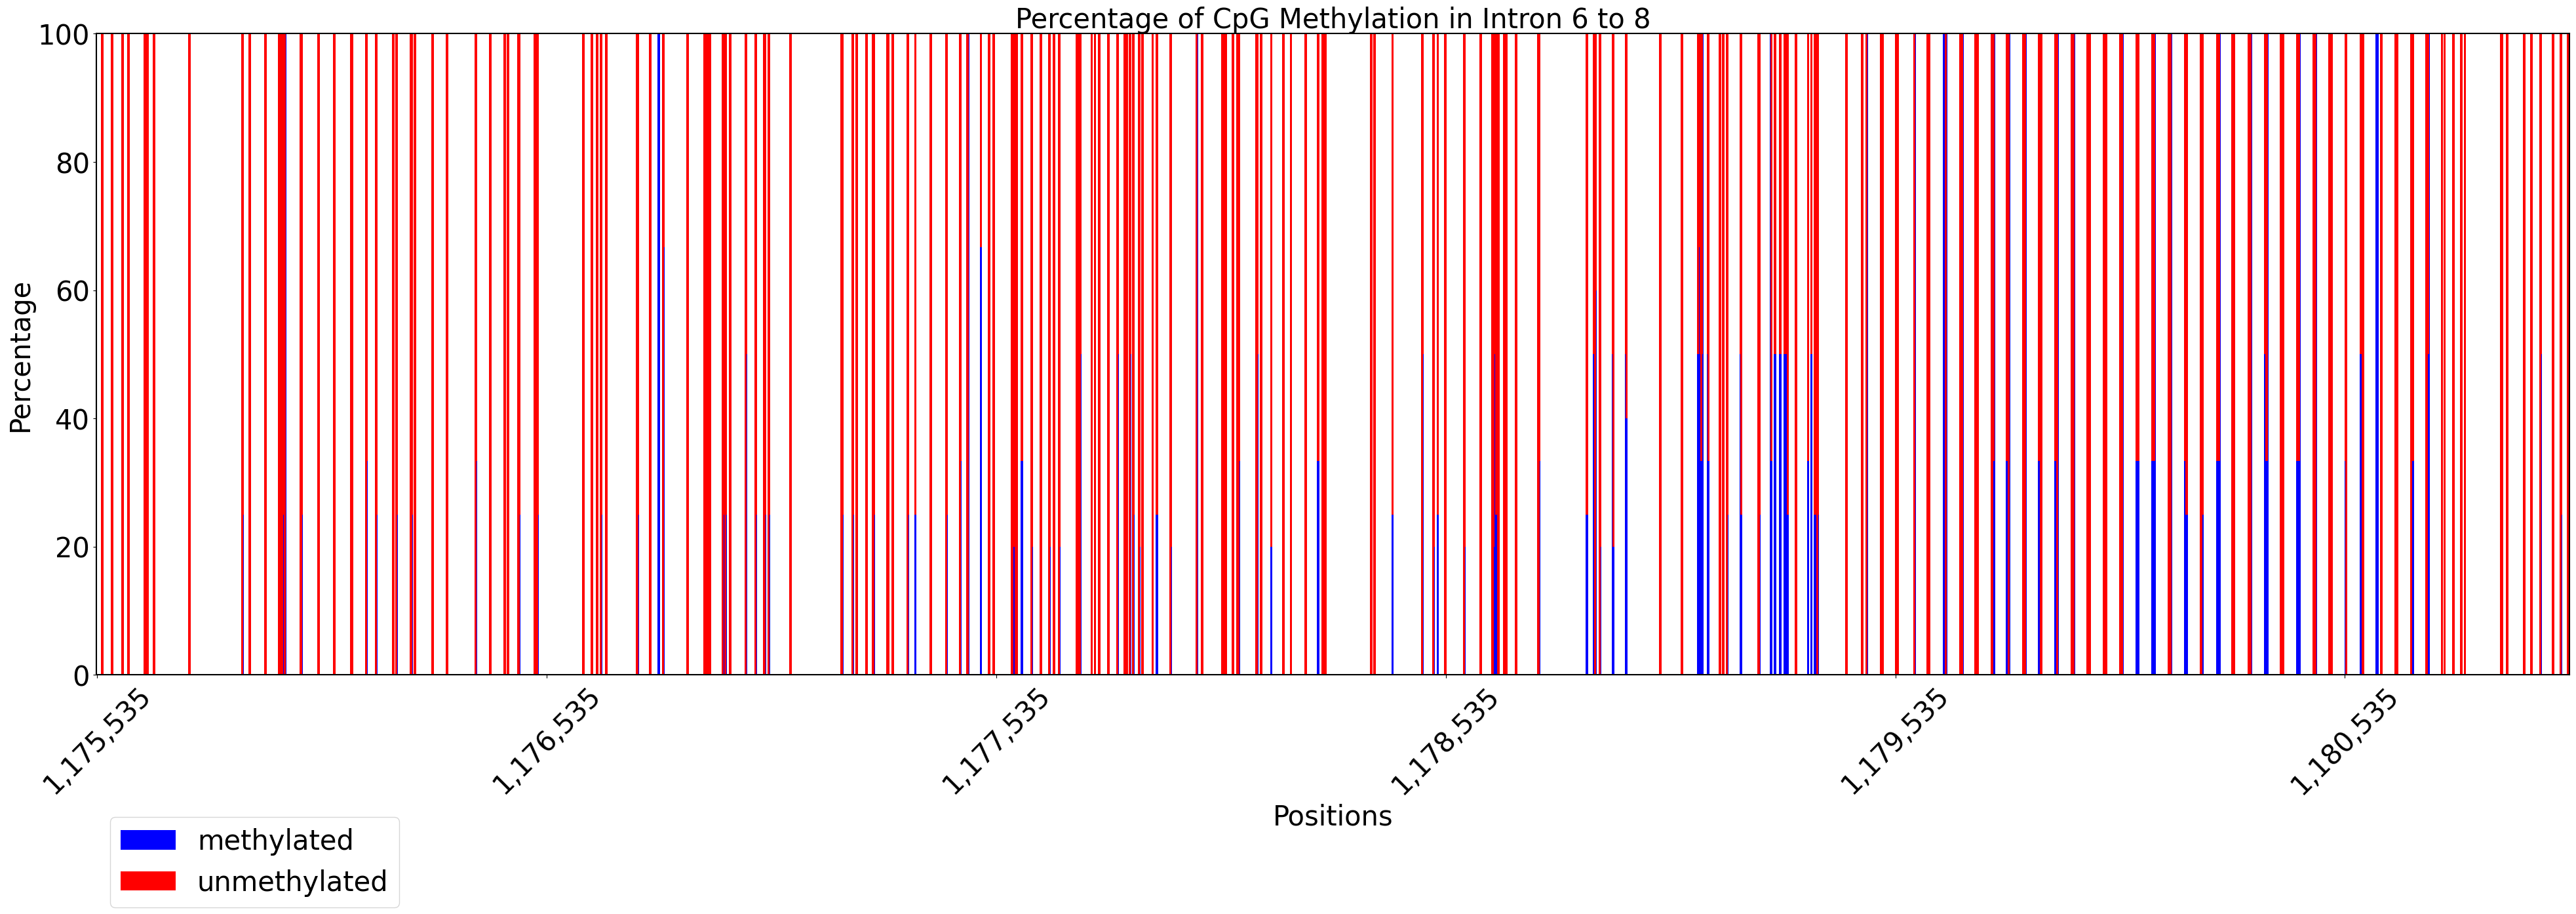

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


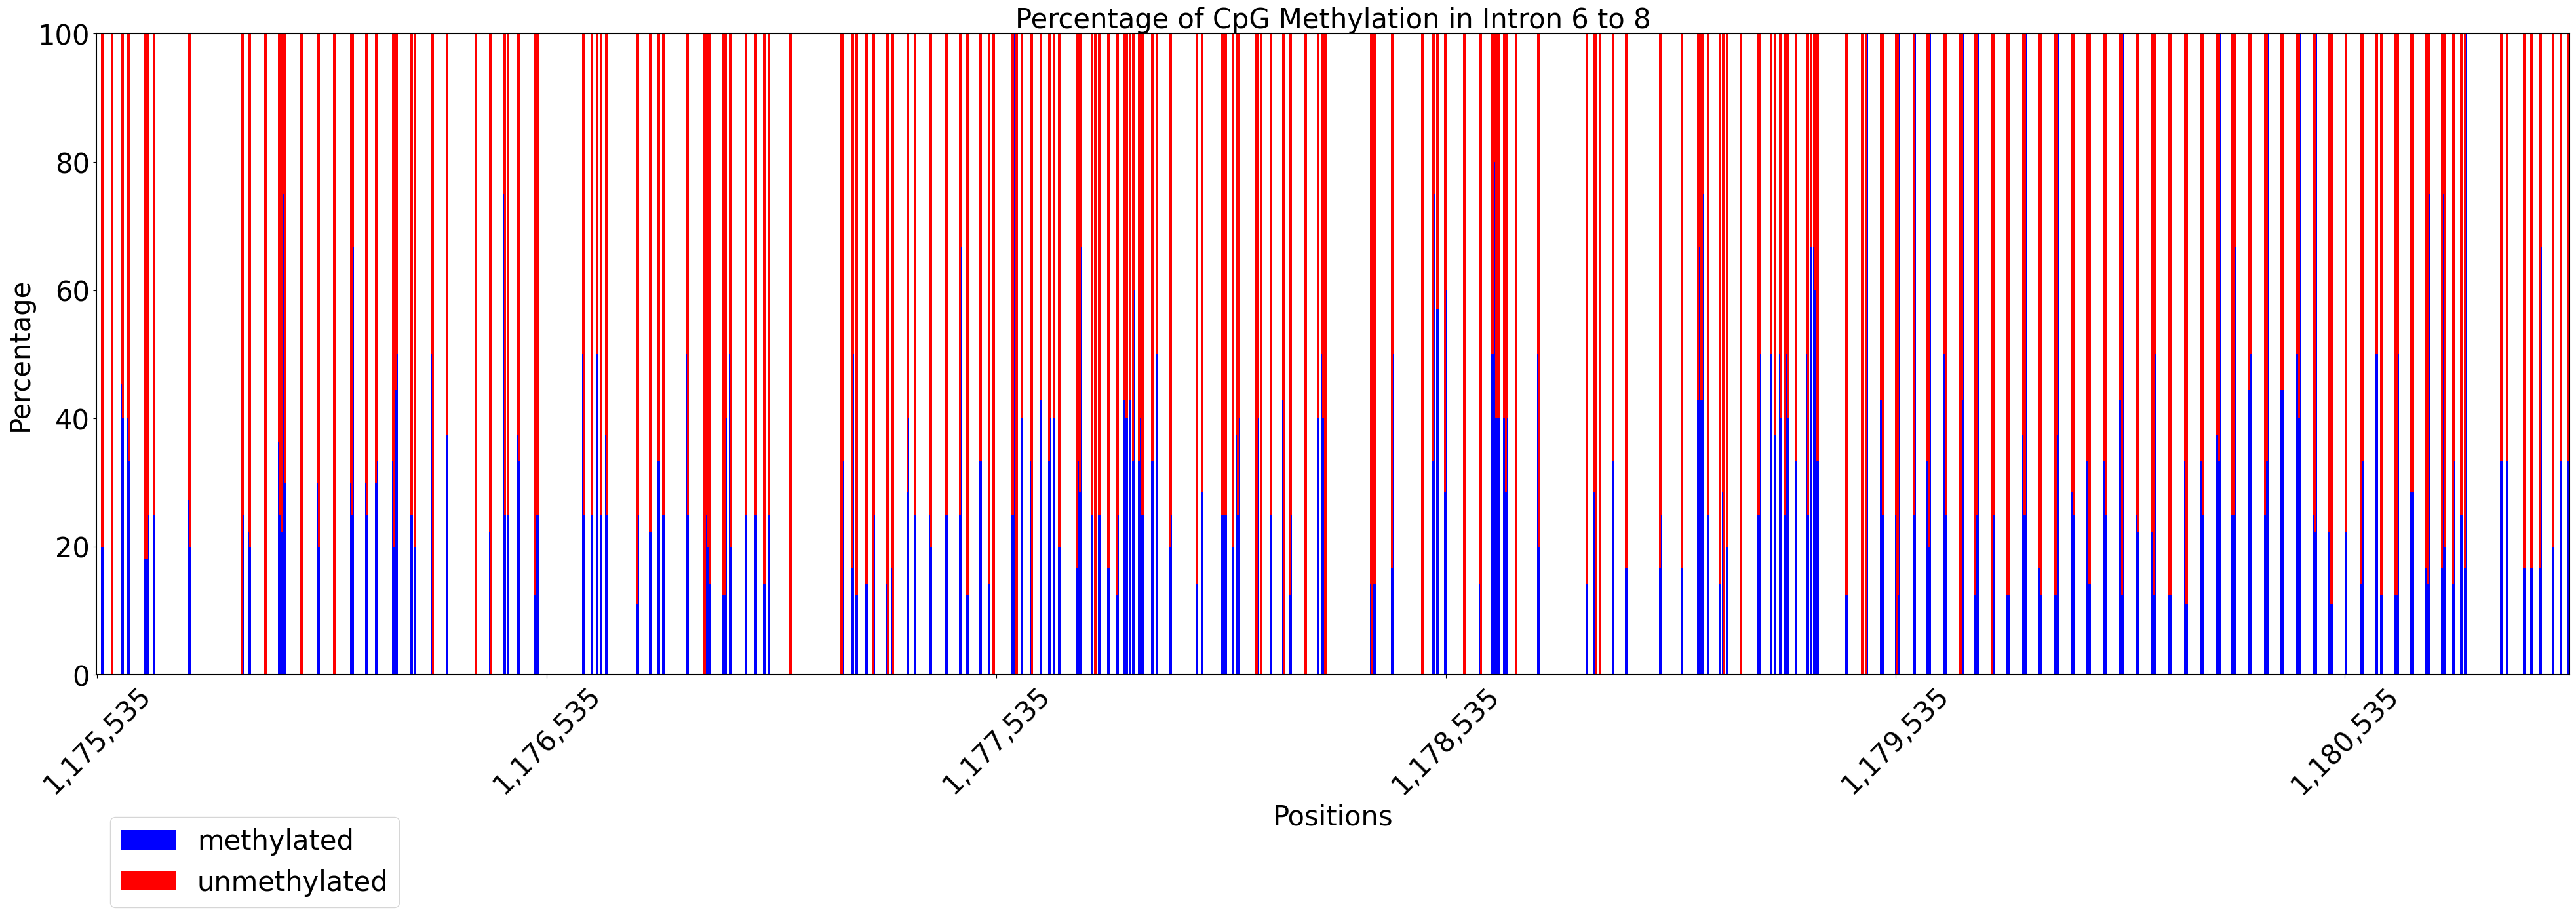

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.bed


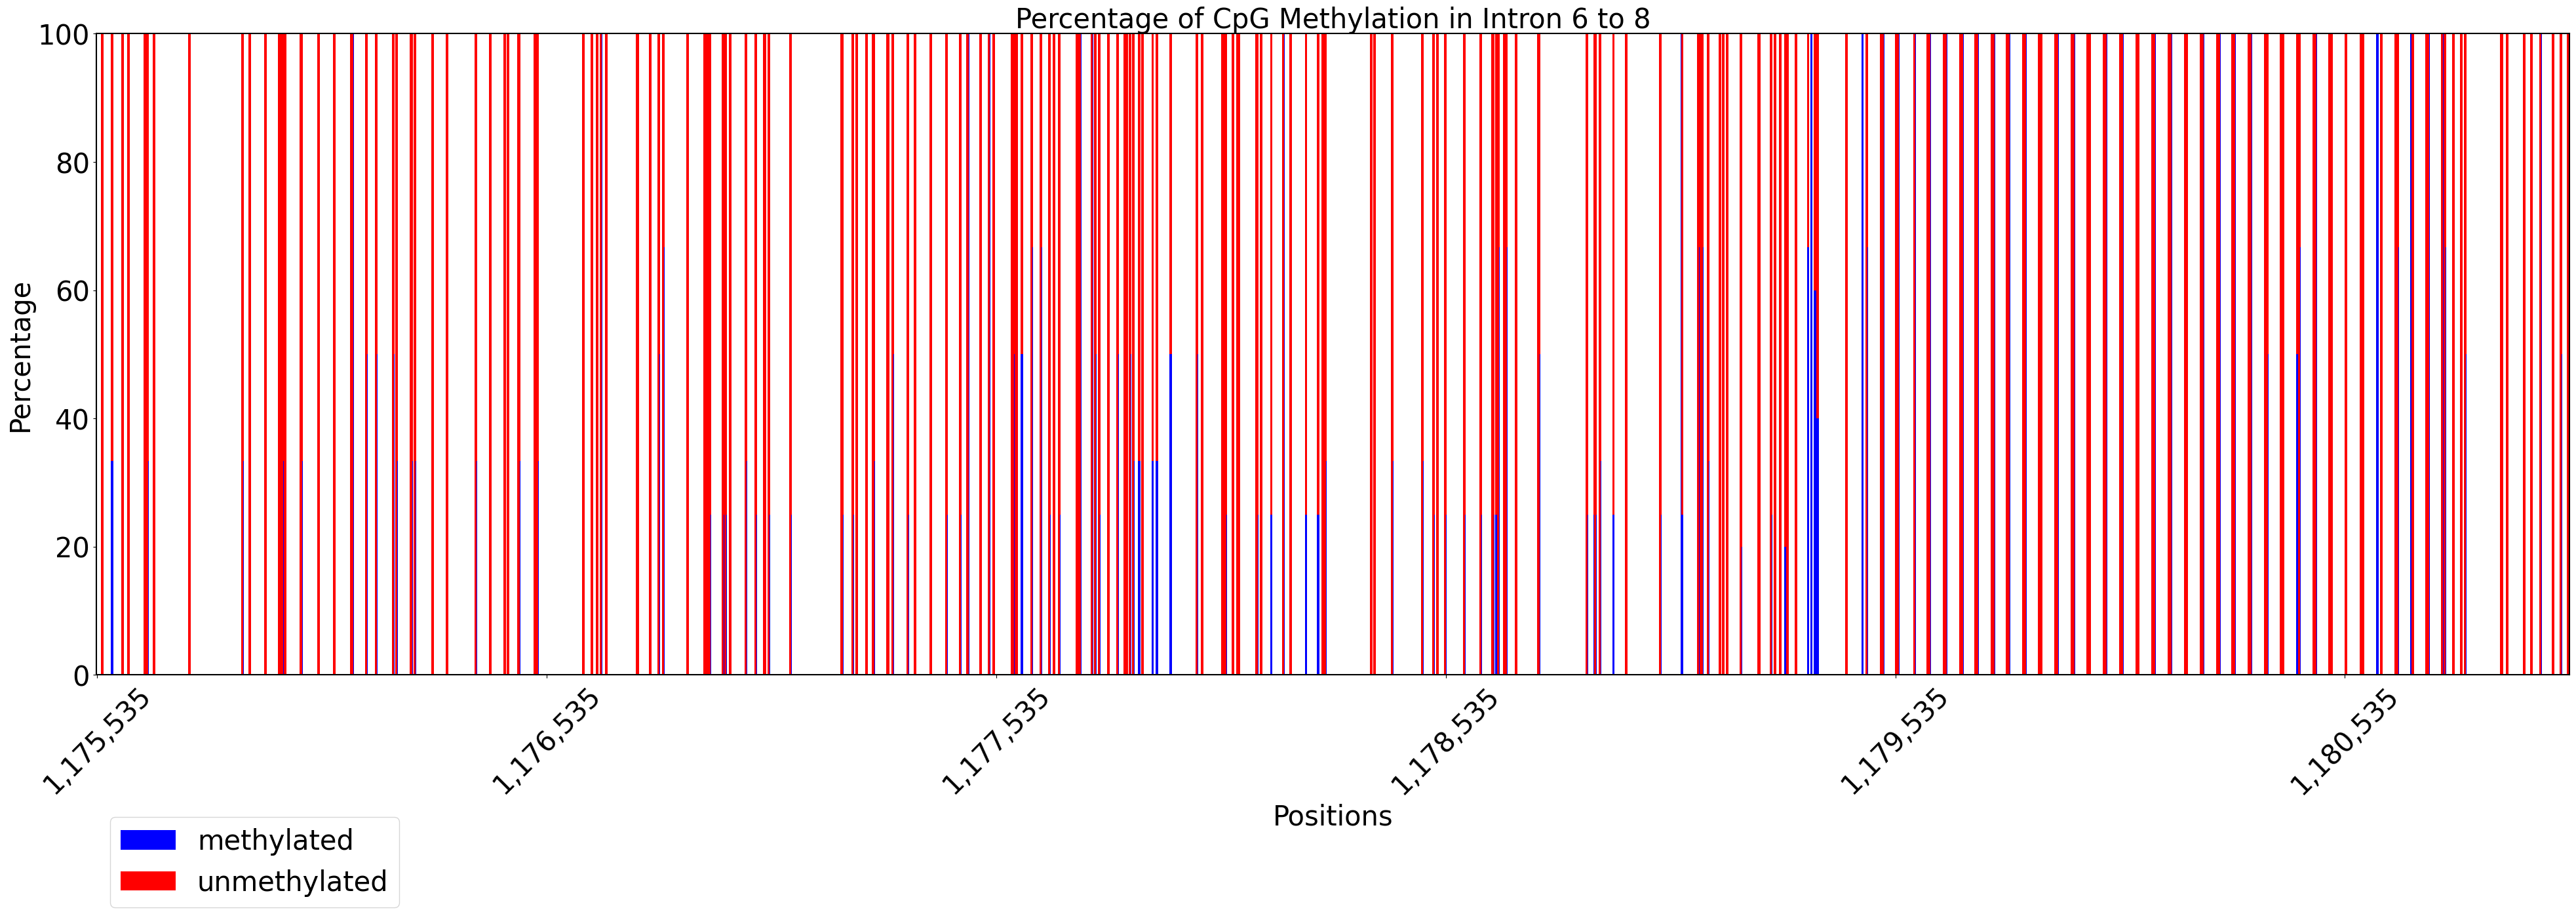

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_unclassified.bam.aligned.bam.sorted.bam.bed


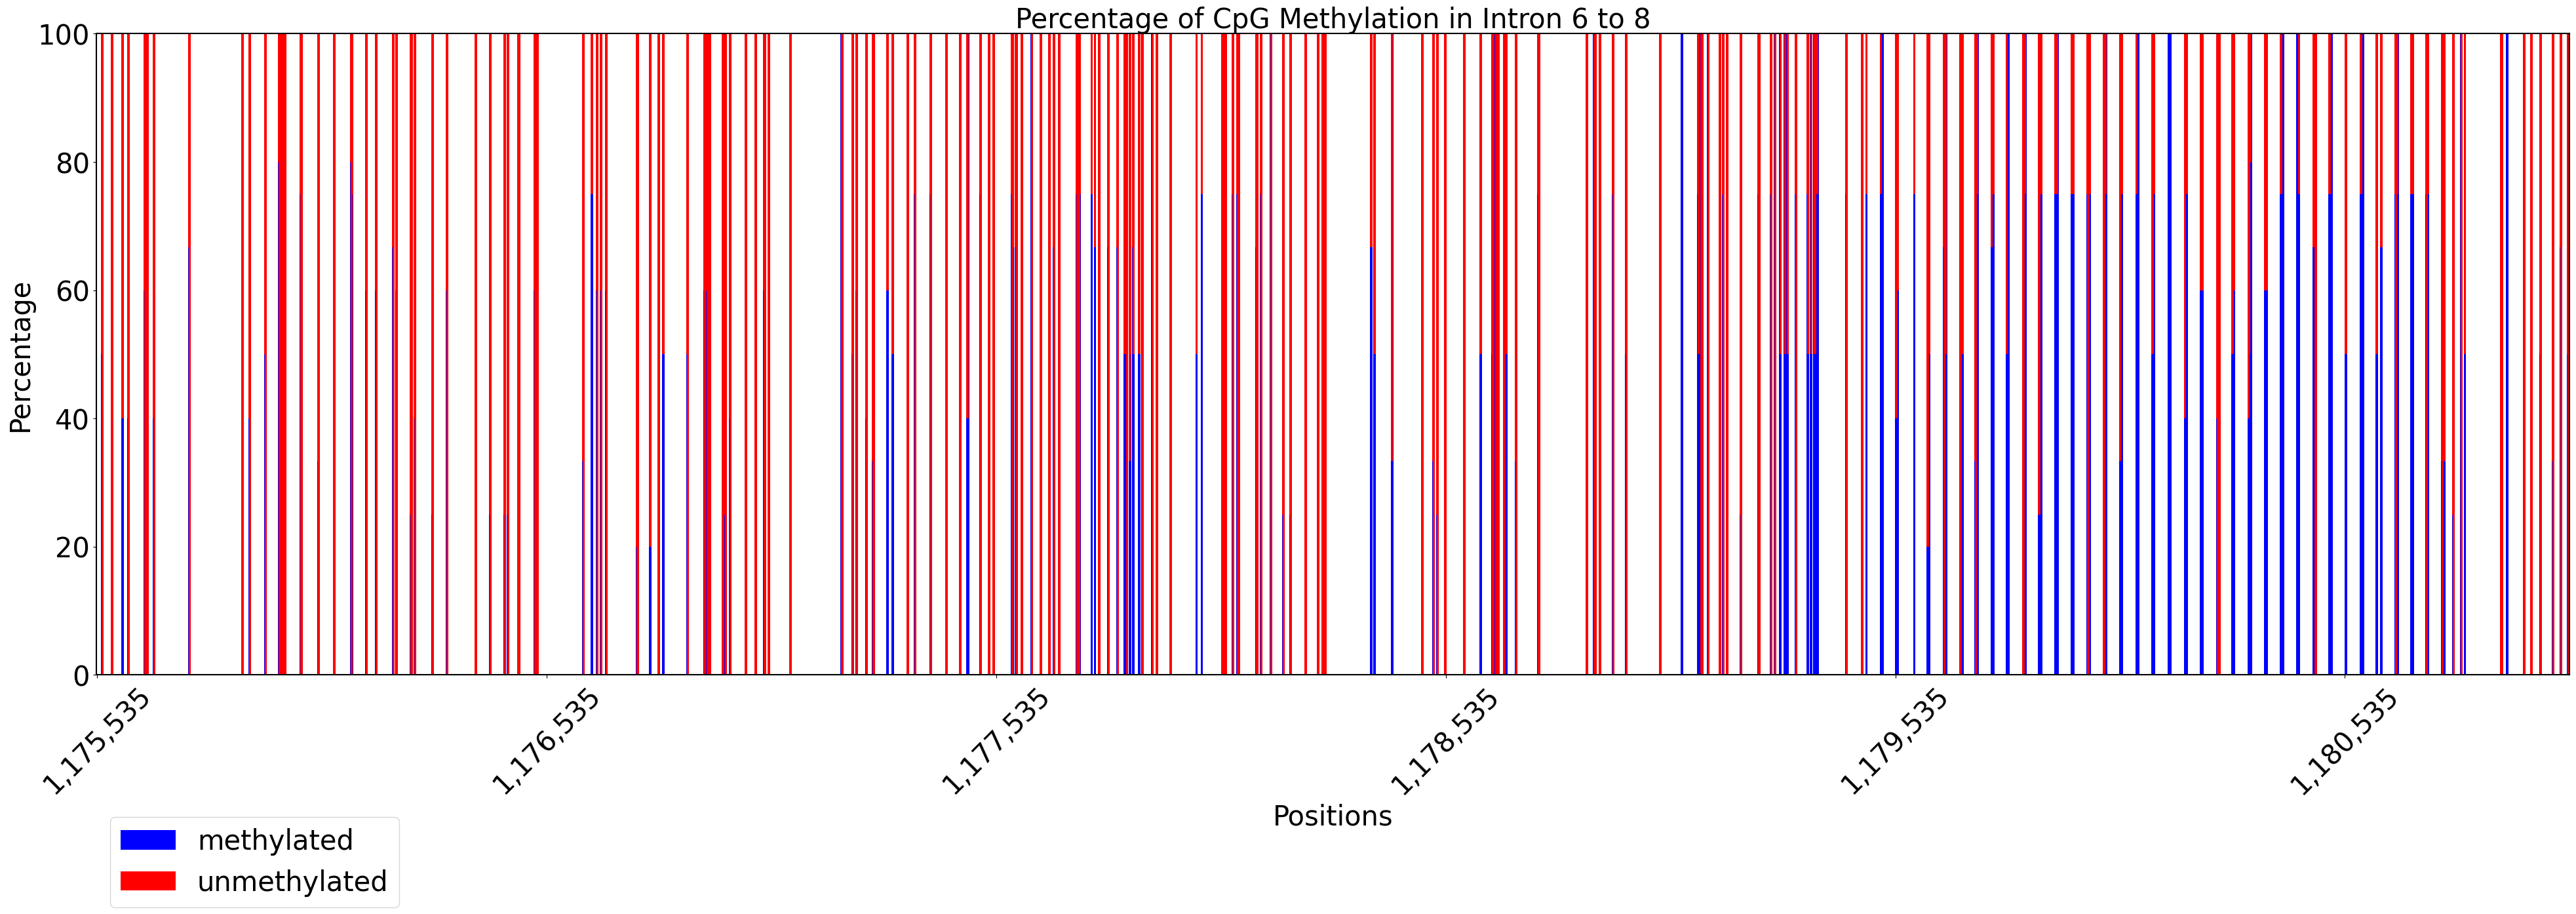

In [23]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    Intron6t8meth("DORADO_DEMUX/"+f)

## Annotation

In [55]:
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc1.fa","r")

annot = {}

count = 1175534

for line in file:
    a = list(line)
    for i in a:
        count +=1
        annot[count]=0
file.close()   

In [56]:
for k,v in annot.items():
    if k >=1175535 and k<=1175540:
        annot[k]=100
    elif k >=1178026 and k<=1178110:
        annot[k]=100
    elif k >=1179092 and k<=1179186:
        annot[k]=100

/tmp/ipykernel_2881556/249408586.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


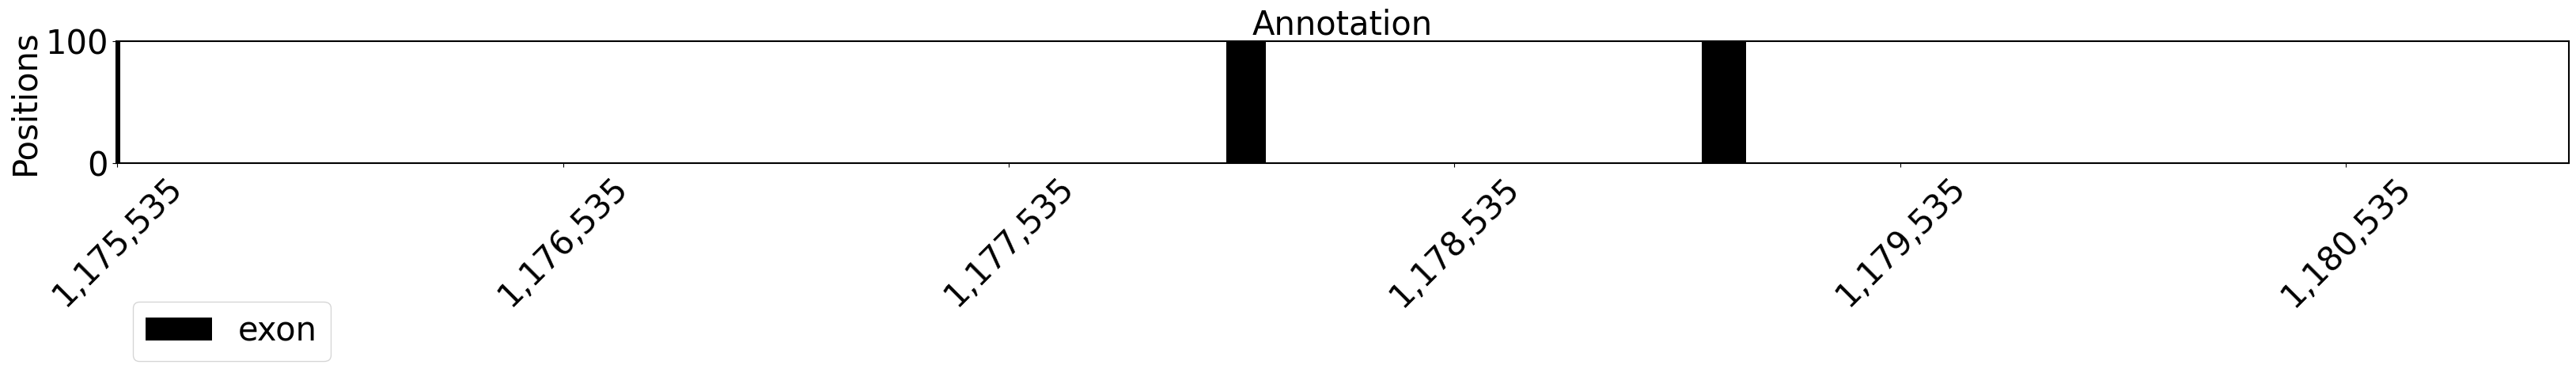

In [57]:
fig = plt.gcf()
fig.set_size_inches(40,2)
plt.rcParams.update({'font.size': 30})
outline=mpe.withStroke(linewidth=8, foreground='black')

# Extract keys as x labels and values as separate parts of the stack
x_labels = list(annot.keys())
y1_values = [float(val) for val in annot.values()]  # First part of the stack (converted to float)

# Set positions for x-axis
x = np.arange(len(x_labels))

# Create the stacked bar plot
plt.bar(x, y1_values, label='exon', color='black',align='center',width=5)

# Customize the plot
tick_positions = np.arange(0, len(x_labels), 1000)  # Show ticks every 100 positions
tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=30)  # Rotate x labels for better visibility
plt.xlabel("", fontsize=30)
plt.ylabel("Positions", fontsize=30)
plt.title("Annotation", fontsize=30)
plt.legend(bbox_to_anchor=(0, -1), loc='upper left')

# Add a border around the plot
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.margins(0)
plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/Intron6to8Annotation.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.tight_layout()
plt.show()

# TAPAS

## Coverage

In [33]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1196006-1205278 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1196006-1205278 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1196006-1205278 | wc -l; done

HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam
Average depth: 24.6711
Standard deviation: 1.27907
66
60


In [42]:
file = open("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/TAPAS_reads.bam","r")

reads = []
Fstrand = []
Rstrand = []

for line in file:
    cols = line.split("\t")
    reads.append(float(len(cols[9])))
    if int(cols[1])==16 or int(cols[1])==272 or int(cols[1])==2064:
        Rstrand.append(float(len(cols[9])))
    else:
        Fstrand.append(float(len(cols[9])))
file.close()

/media/data_01/vapatter/CONDA/NOTEBOOK/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


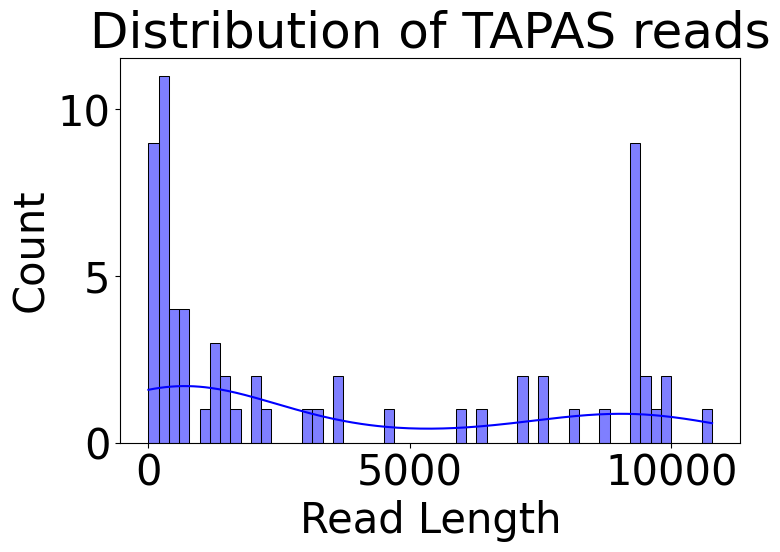

/media/data_01/vapatter/CONDA/NOTEBOOK/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


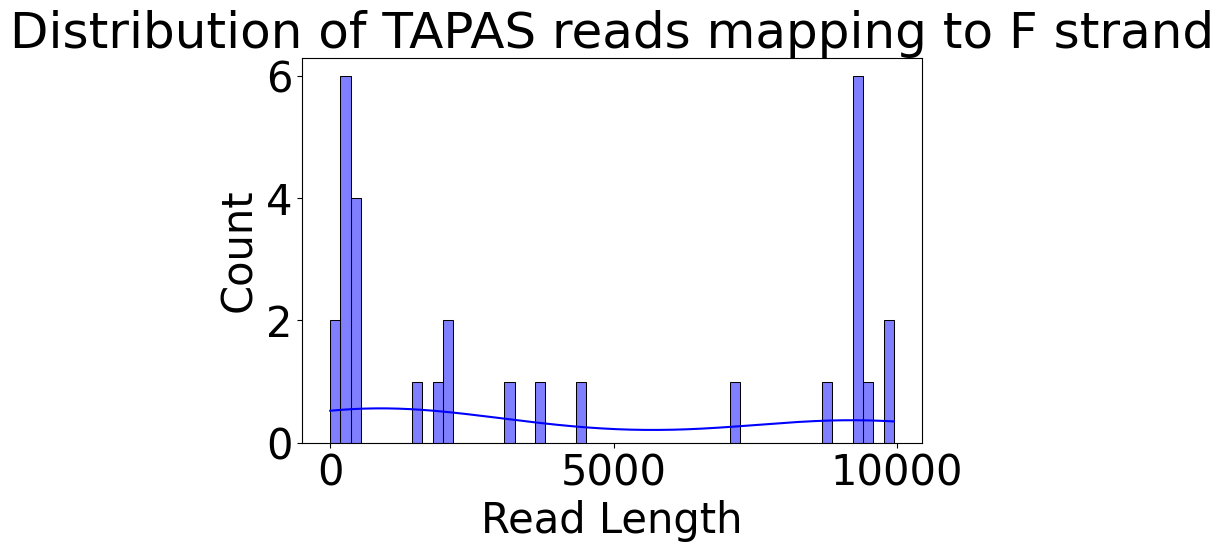

/media/data_01/vapatter/CONDA/NOTEBOOK/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


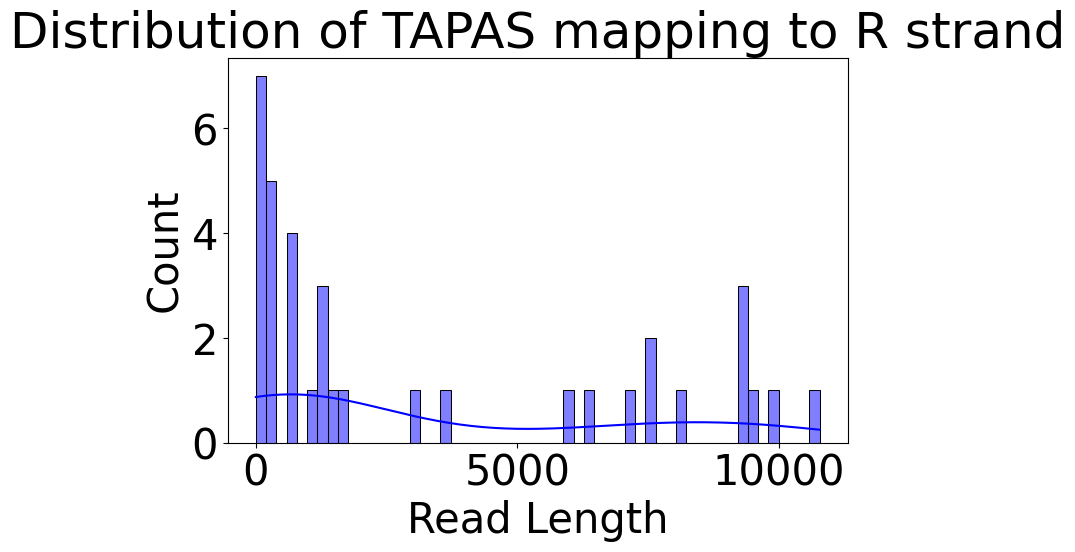

In [44]:
import seaborn as sns
# Plot distribution
plt.figure(figsize=(8, 5))
sns.histplot(reads, kde=True, bins=55, color='blue', edgecolor='black')
# Labels and title
plt.xlabel('Read Length')
plt.ylabel('Count')
plt.title('Distribution of TAPAS reads')
# Show plot
plt.show()
plt.figure(figsize=(8, 5))
sns.histplot(Fstrand, kde=True, bins=55, color='blue', edgecolor='black')
# Labels and title
plt.xlabel('Read Length')
plt.ylabel('Count')
plt.title('Distribution of TAPAS reads mapping to F strand')
# Show plot
plt.show()
plt.figure(figsize=(8, 5))
sns.histplot(Rstrand, kde=True, bins=55, color='blue', edgecolor='black')
# Labels and title
plt.xlabel('Read Length')
plt.ylabel('Count')
plt.title('Distribution of TAPAS mapping to R strand')
# Show plot
plt.show()

In [10]:
%%bash
cd /media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX
for f in *sorted.bam; do 
ls $f
samtools depth -r NC_060929.1:1196006-1205278 $f | awk '
{
    sum += $3;                          # Sum of depths
    sumsq += $3 * $3;                   # Sum of squares of depths
    count++;                             # Count of positions
}
END {
    if (count > 0) {
        avg = sum / count;               # Average depth
        variance = (sumsq / count) - (avg * avg);  # Variance
        stddev = (variance > 0) ? sqrt(variance) : 0;  # Standard deviation
        print "Average depth:", avg;
        print "Standard deviation:", stddev;
    } else {
        print "No data";
    }
}'
samtools view -F 4 $f NC_060929.1:1196006-1205278 | wc -l
samtools view -F 4 -F 256 $f NC_060929.1:1196006-1205278 | wc -l; done

6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam
Average depth: 8.18624
Standard deviation: 1.4332
21
19
6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam
Average depth: 6.48916
Standard deviation: 1.18989
17
17
6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam
Average depth: 9.3508
Standard deviation: 1.53277
22
21
6625ff67fb7d802182a83888398d8e73dbfd09d5_unclassified.bam.aligned.bam.sorted.bam
Average depth: 1.01425
Standard deviation: 0.165146
6
3


HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


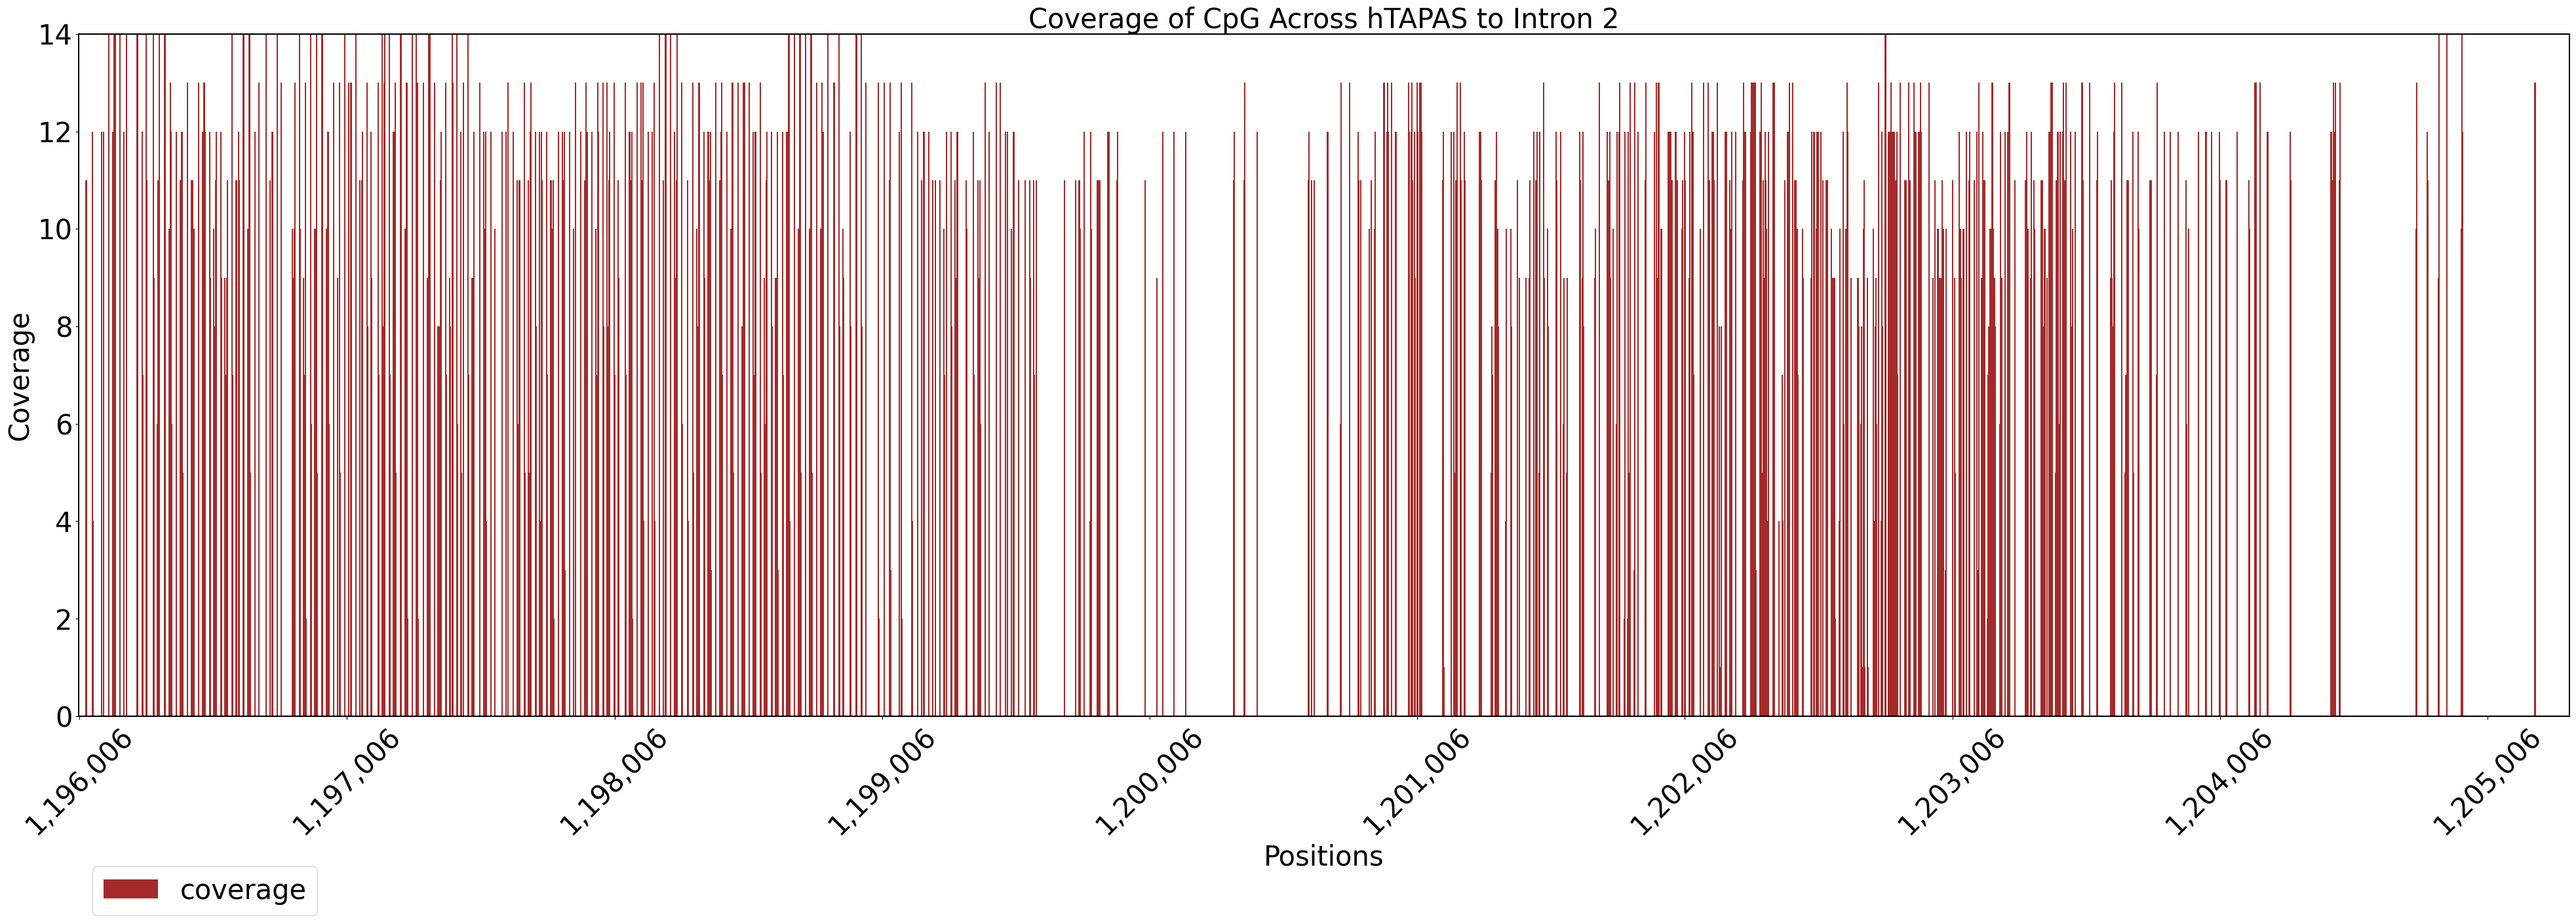

In [56]:
TAPAScov("HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed")

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.bed


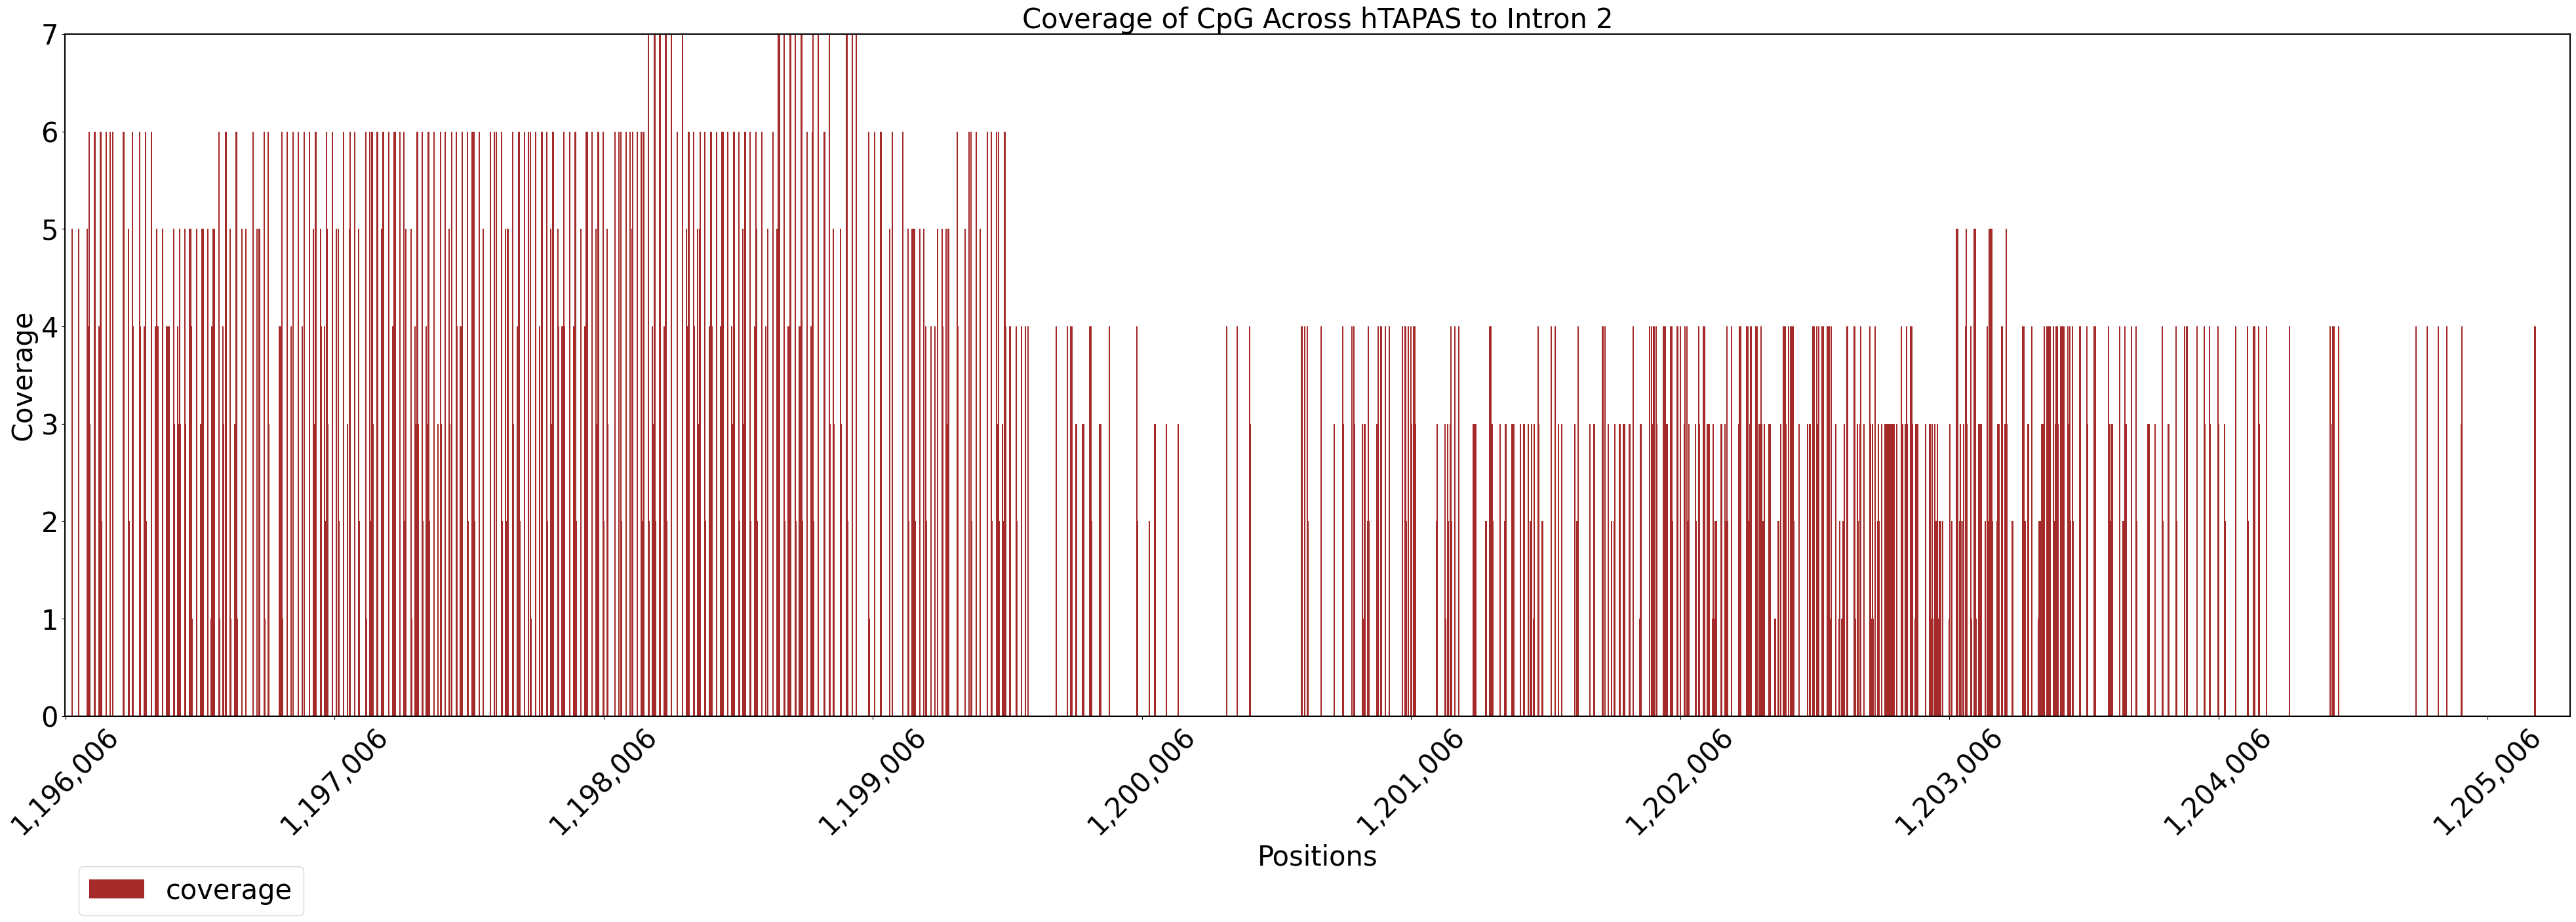

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


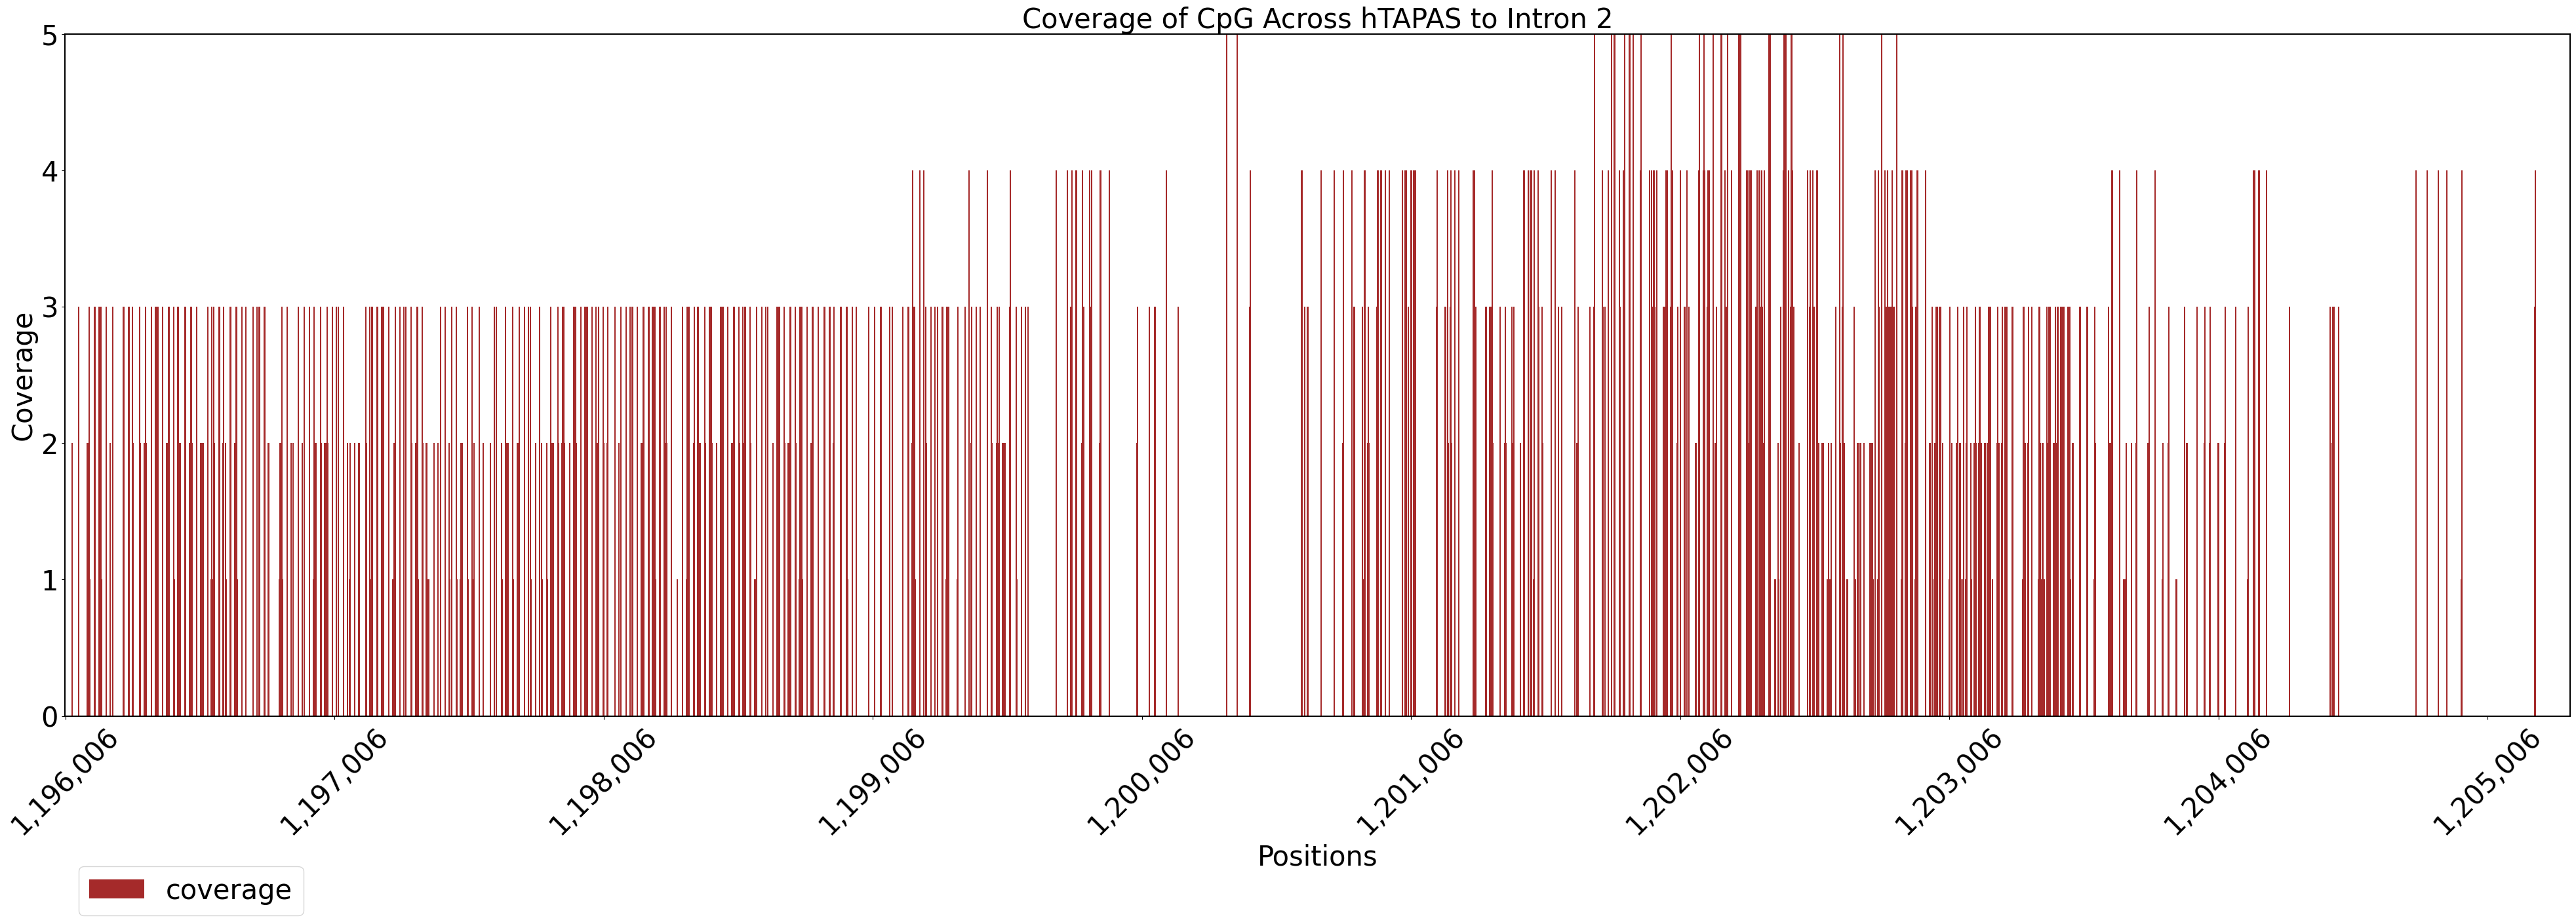

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.bed


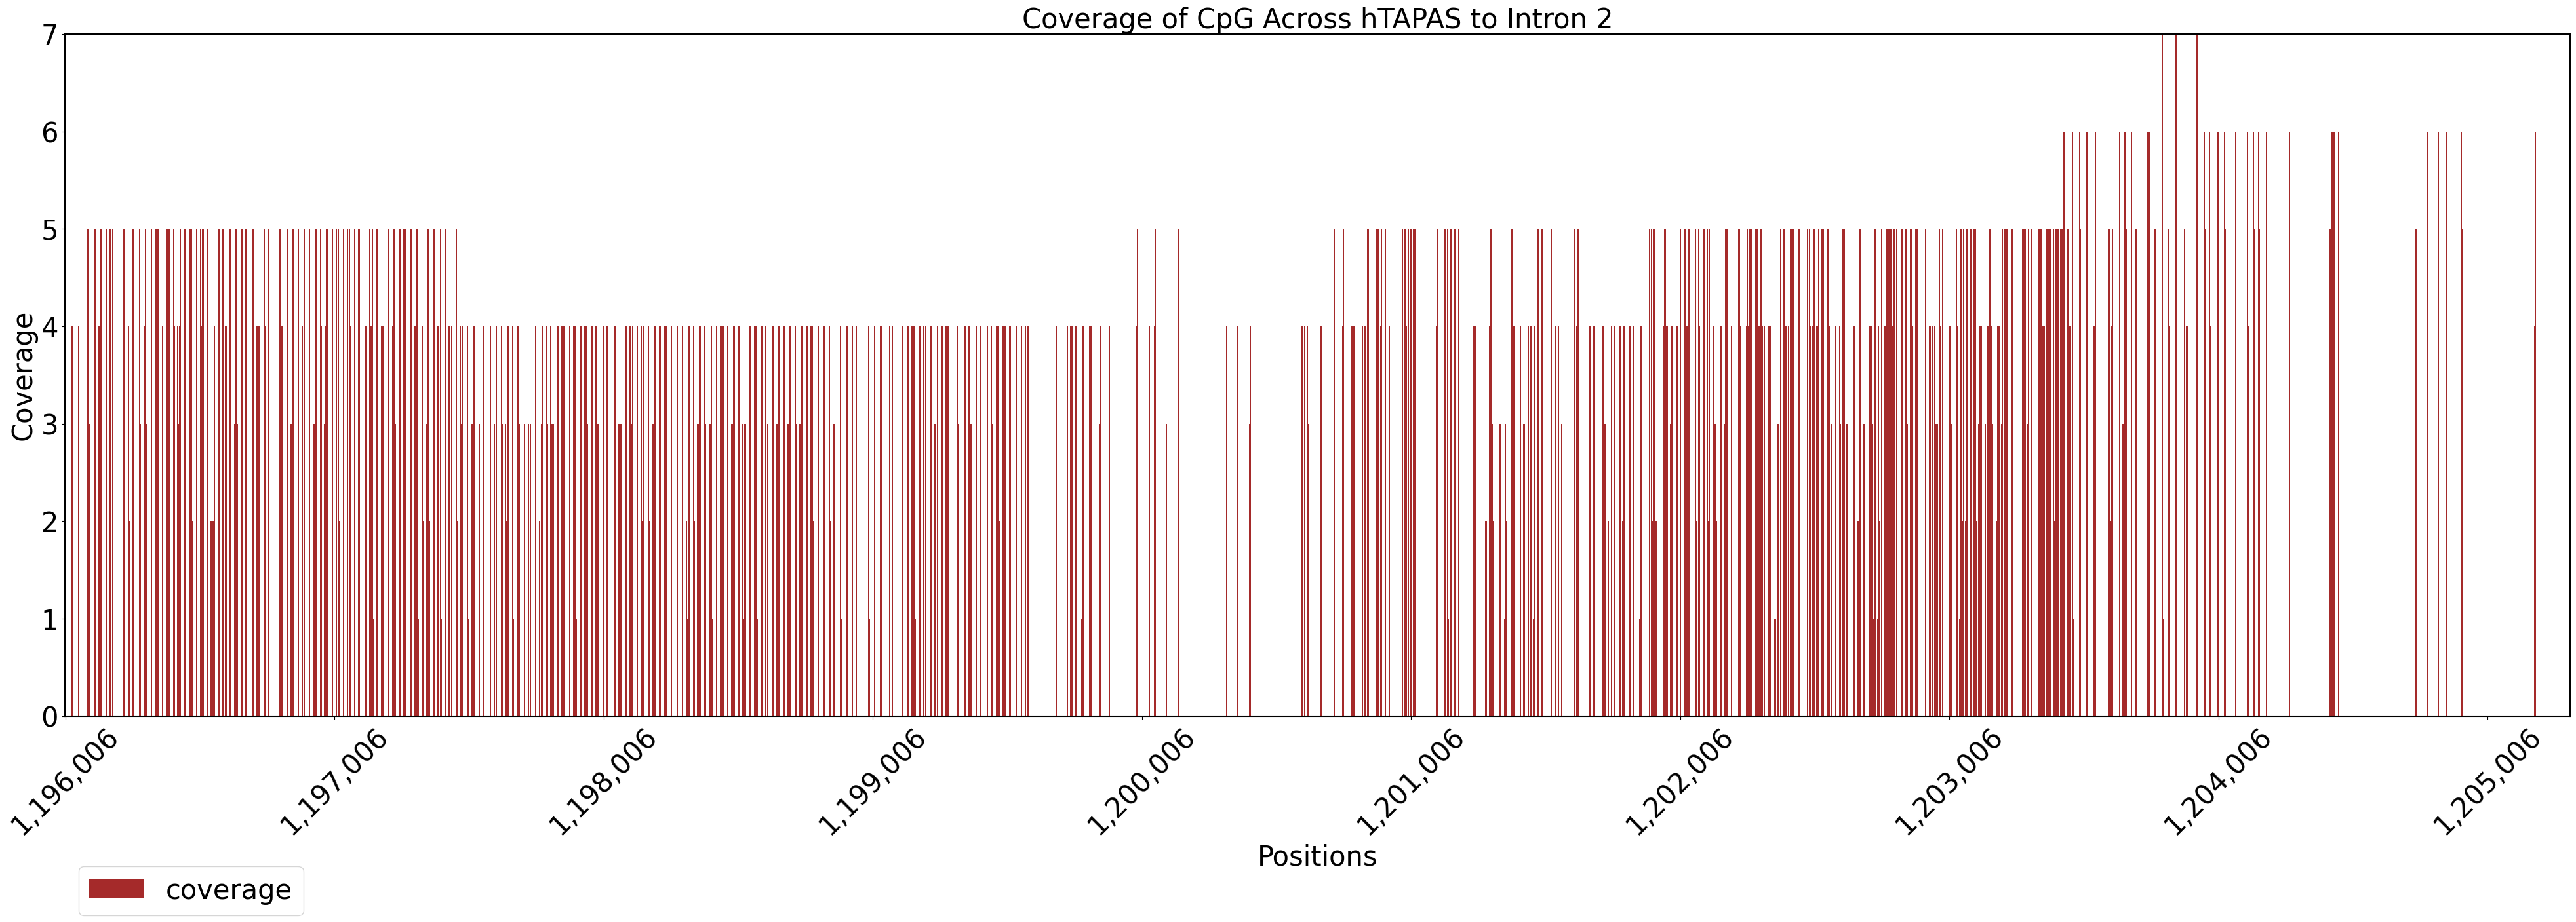

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_unclassified.bam.aligned.bam.sorted.bam.bed


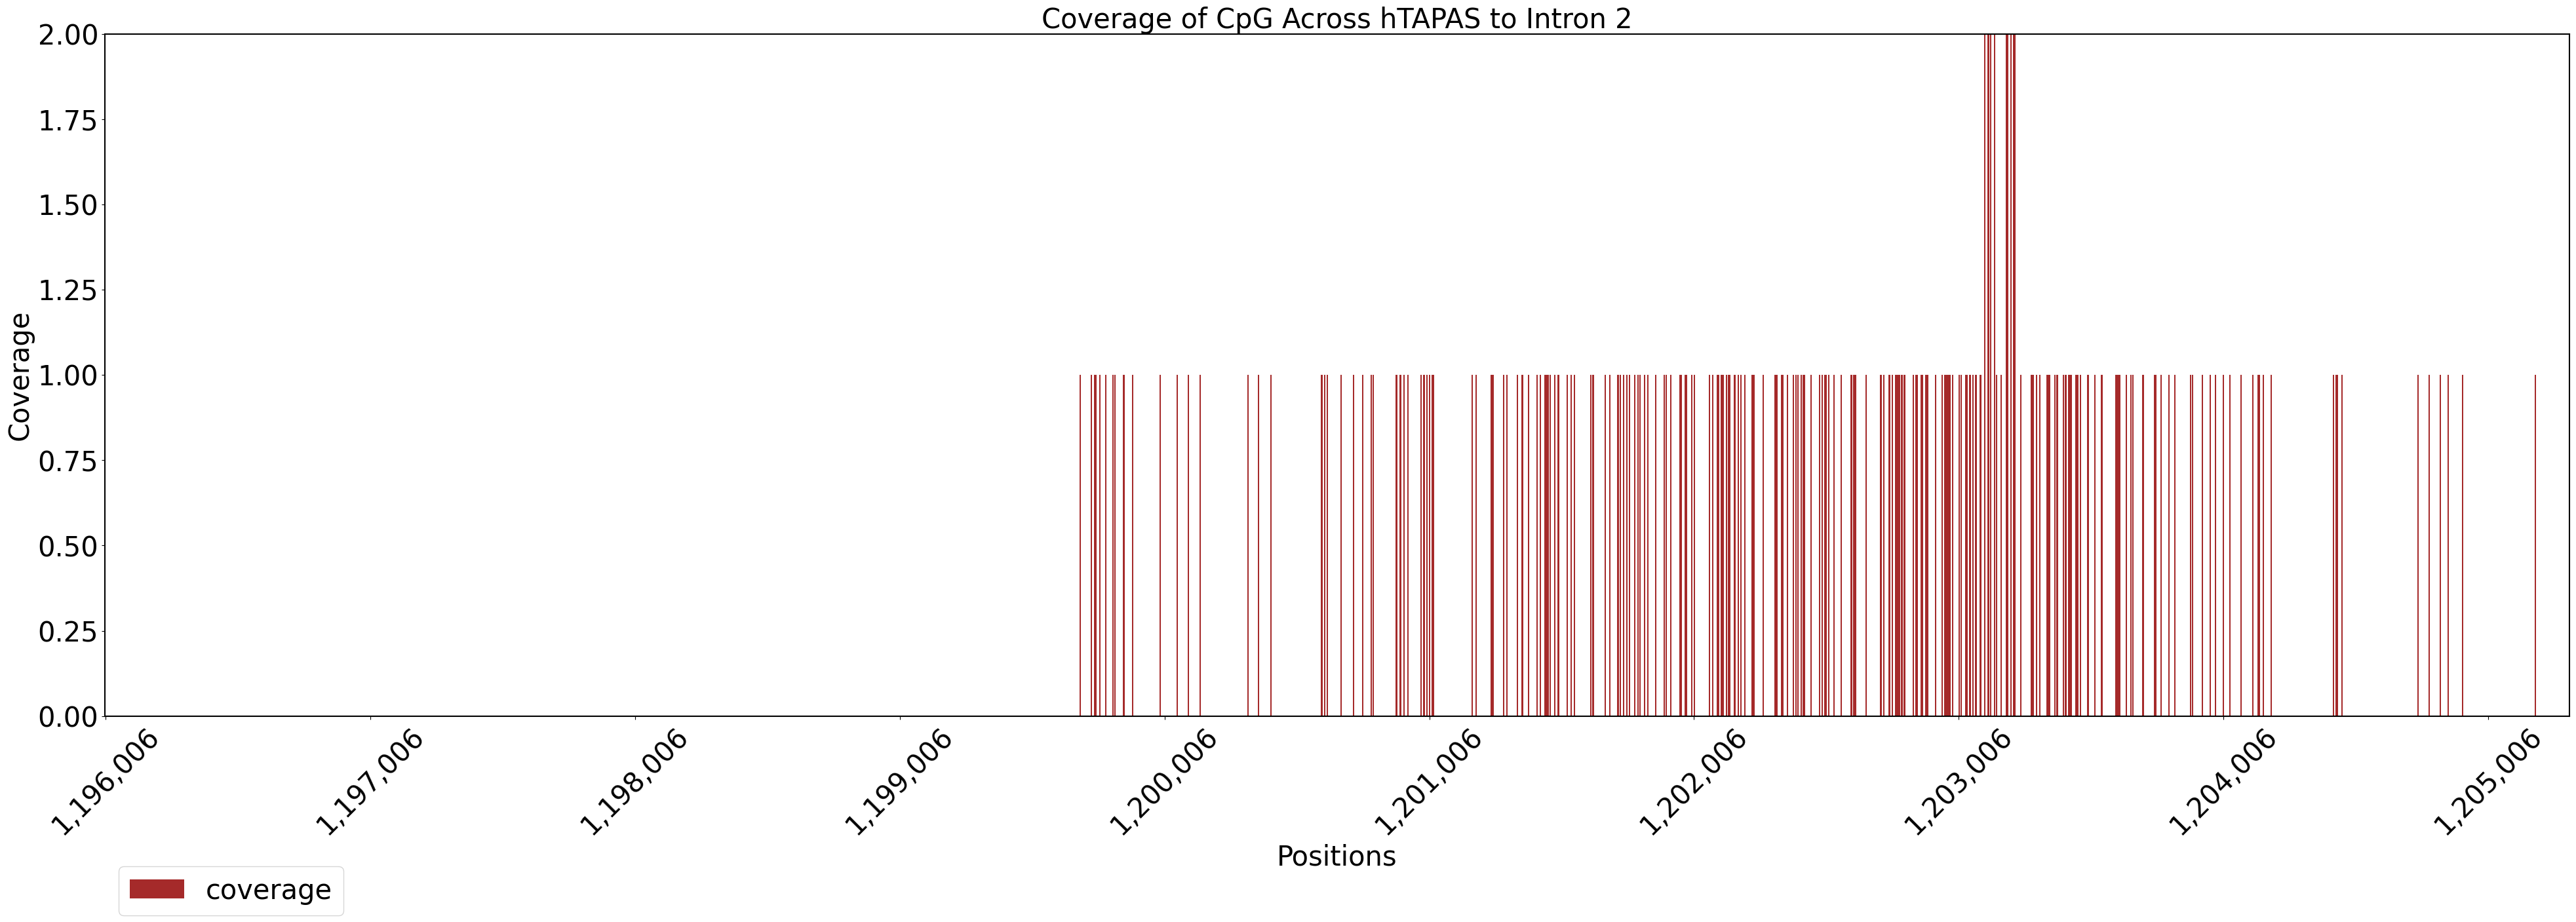

In [22]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    TAPAScov("DORADO_DEMUX/"+f)

## Methylation

HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed


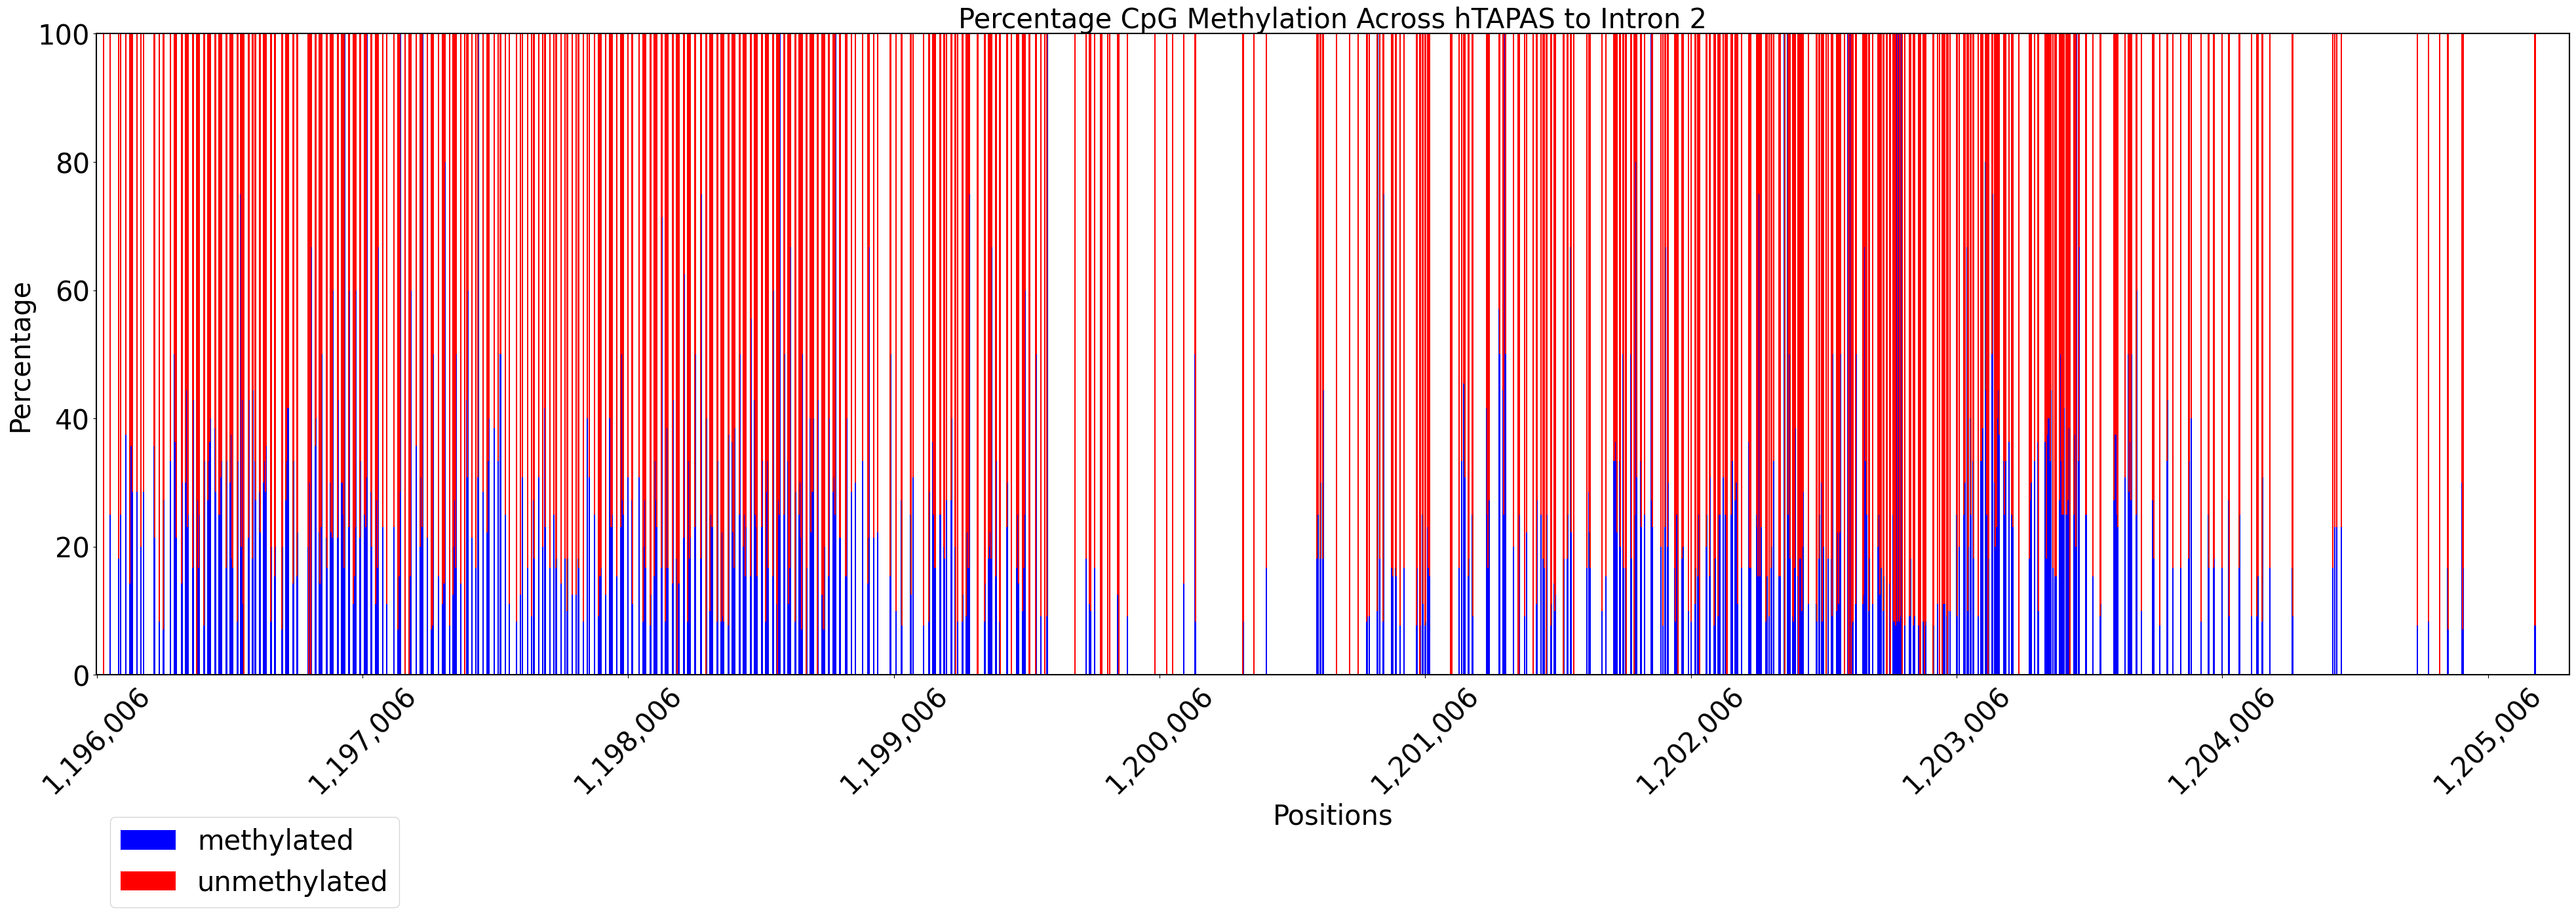

In [53]:
TAPASmeth("HEK_Aza_cutsitetest_CRISPR_T2T-CHM13v2.0.dna_r10.4.1_e8.2_400bps_sup@v4.3.0.bam.sorted.bam.bed")

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode13.bam.aligned.bam.sorted.bam.bed


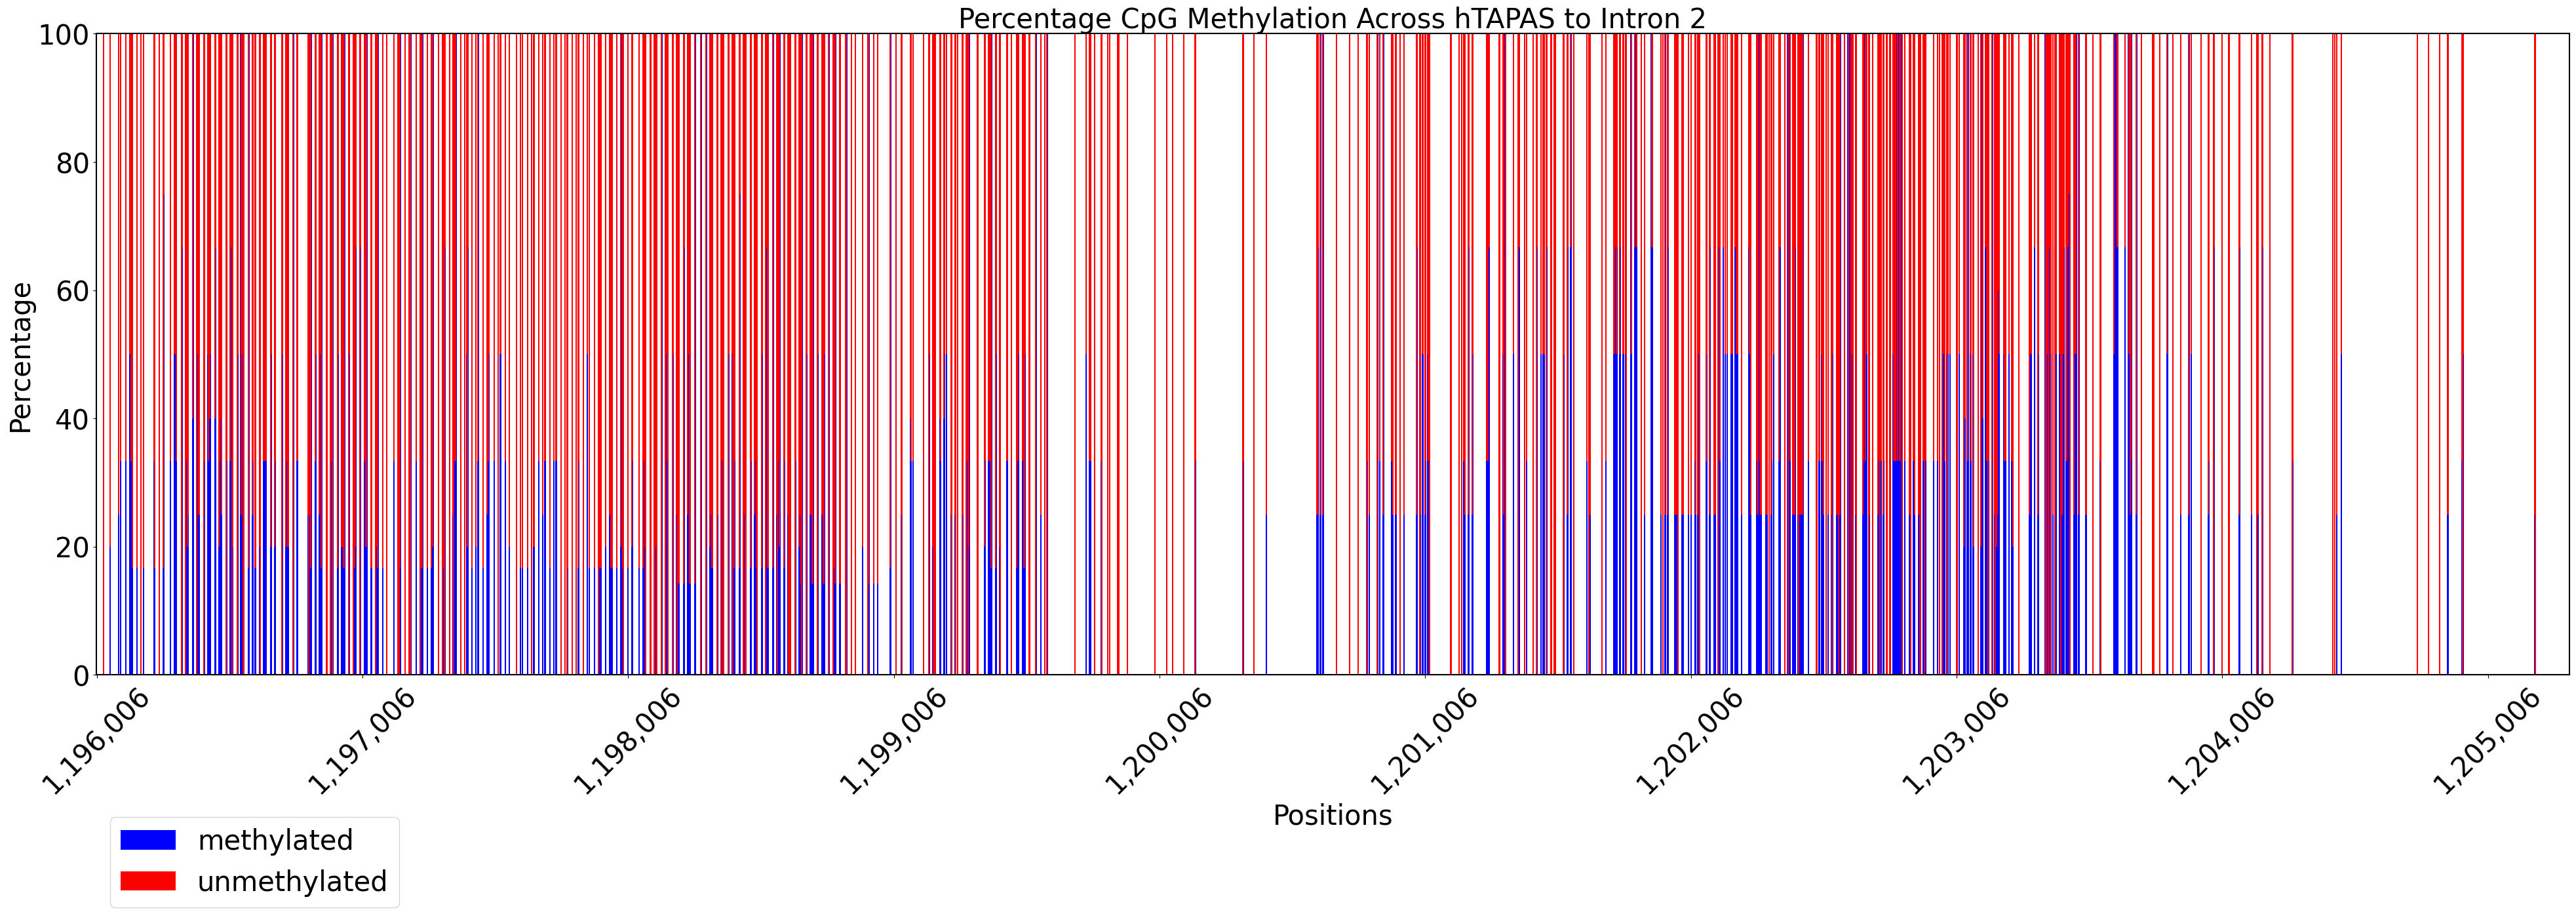

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode22.bam.aligned.bam.sorted.bam.bed


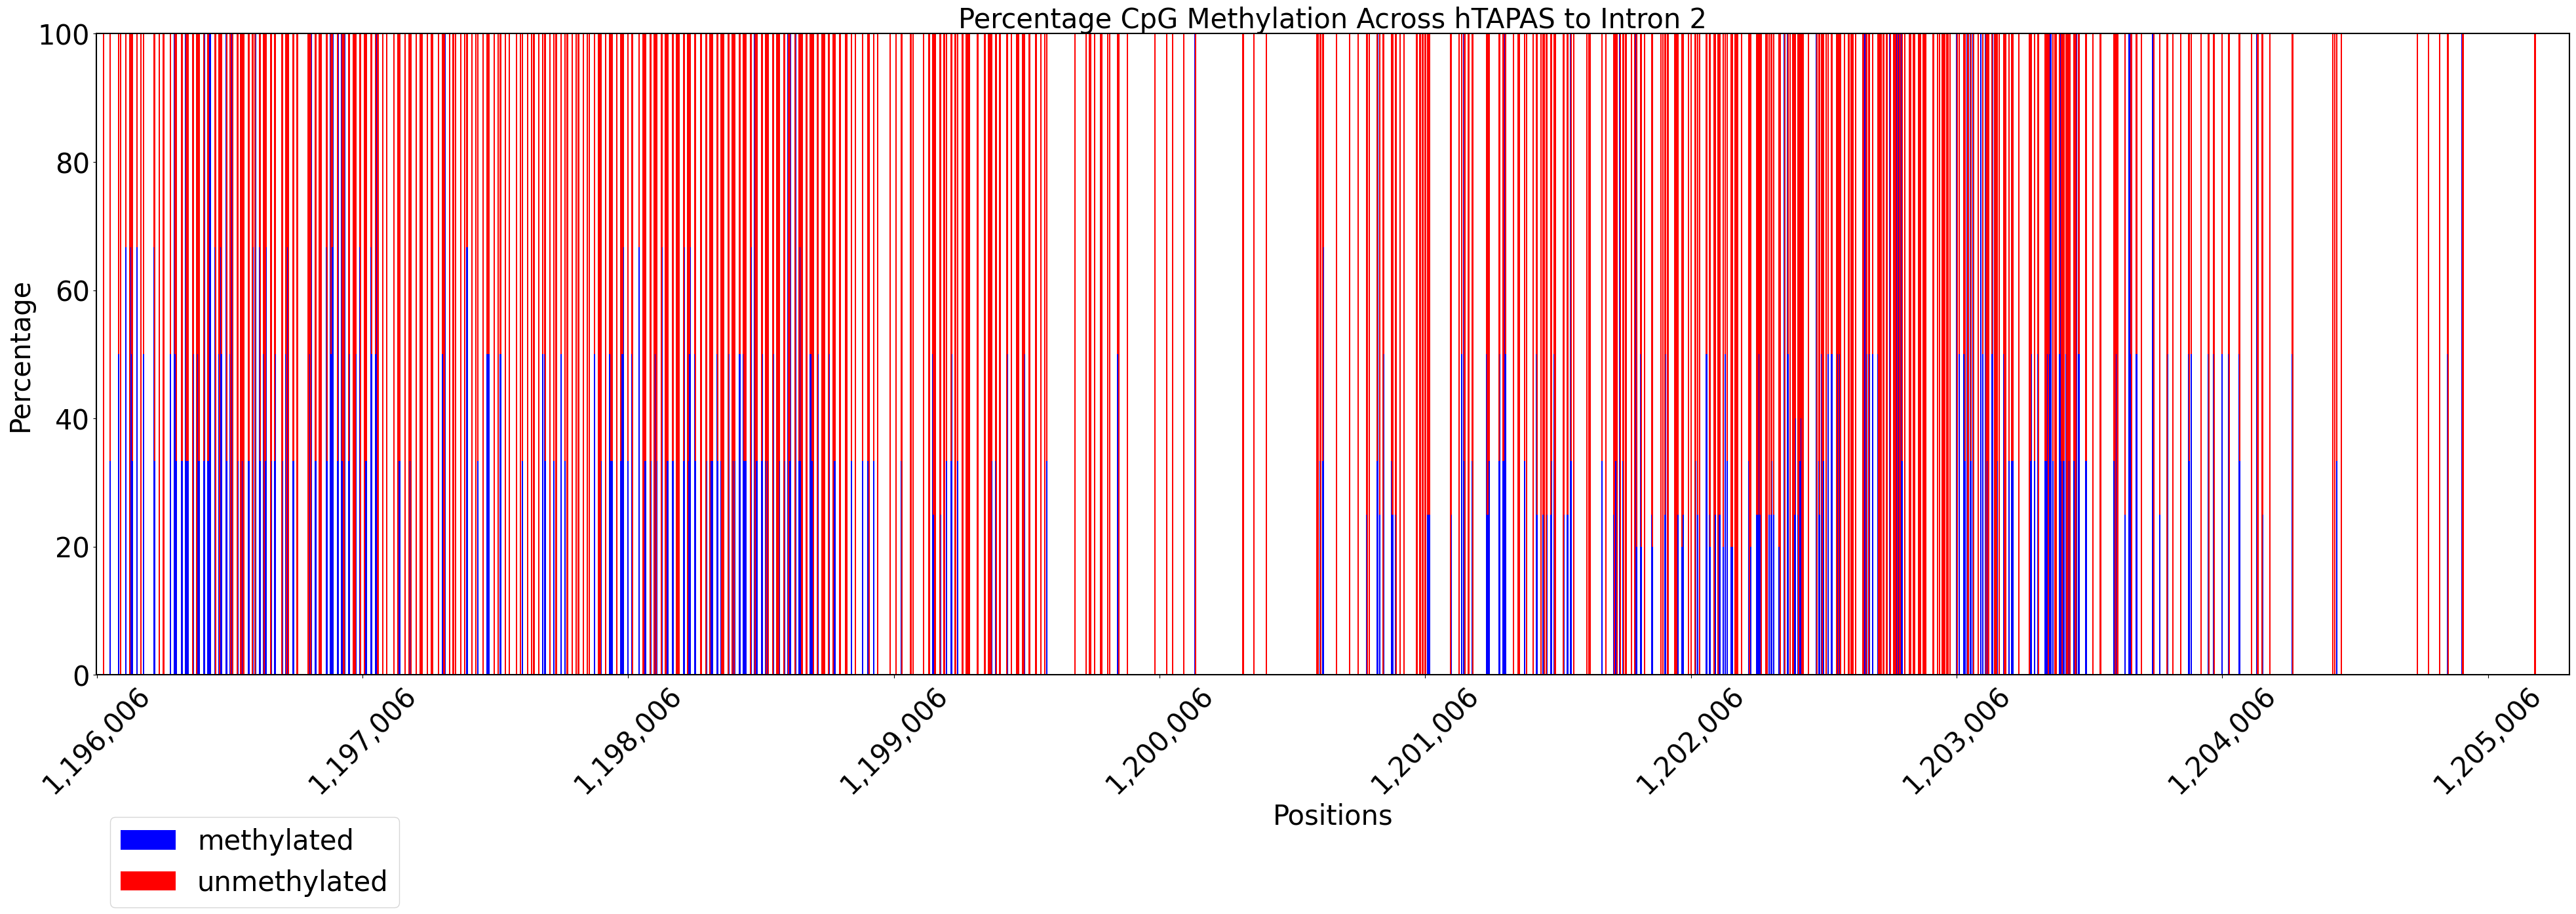

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_EXP-NBD114_barcode24.bam.aligned.bam.sorted.bam.bed


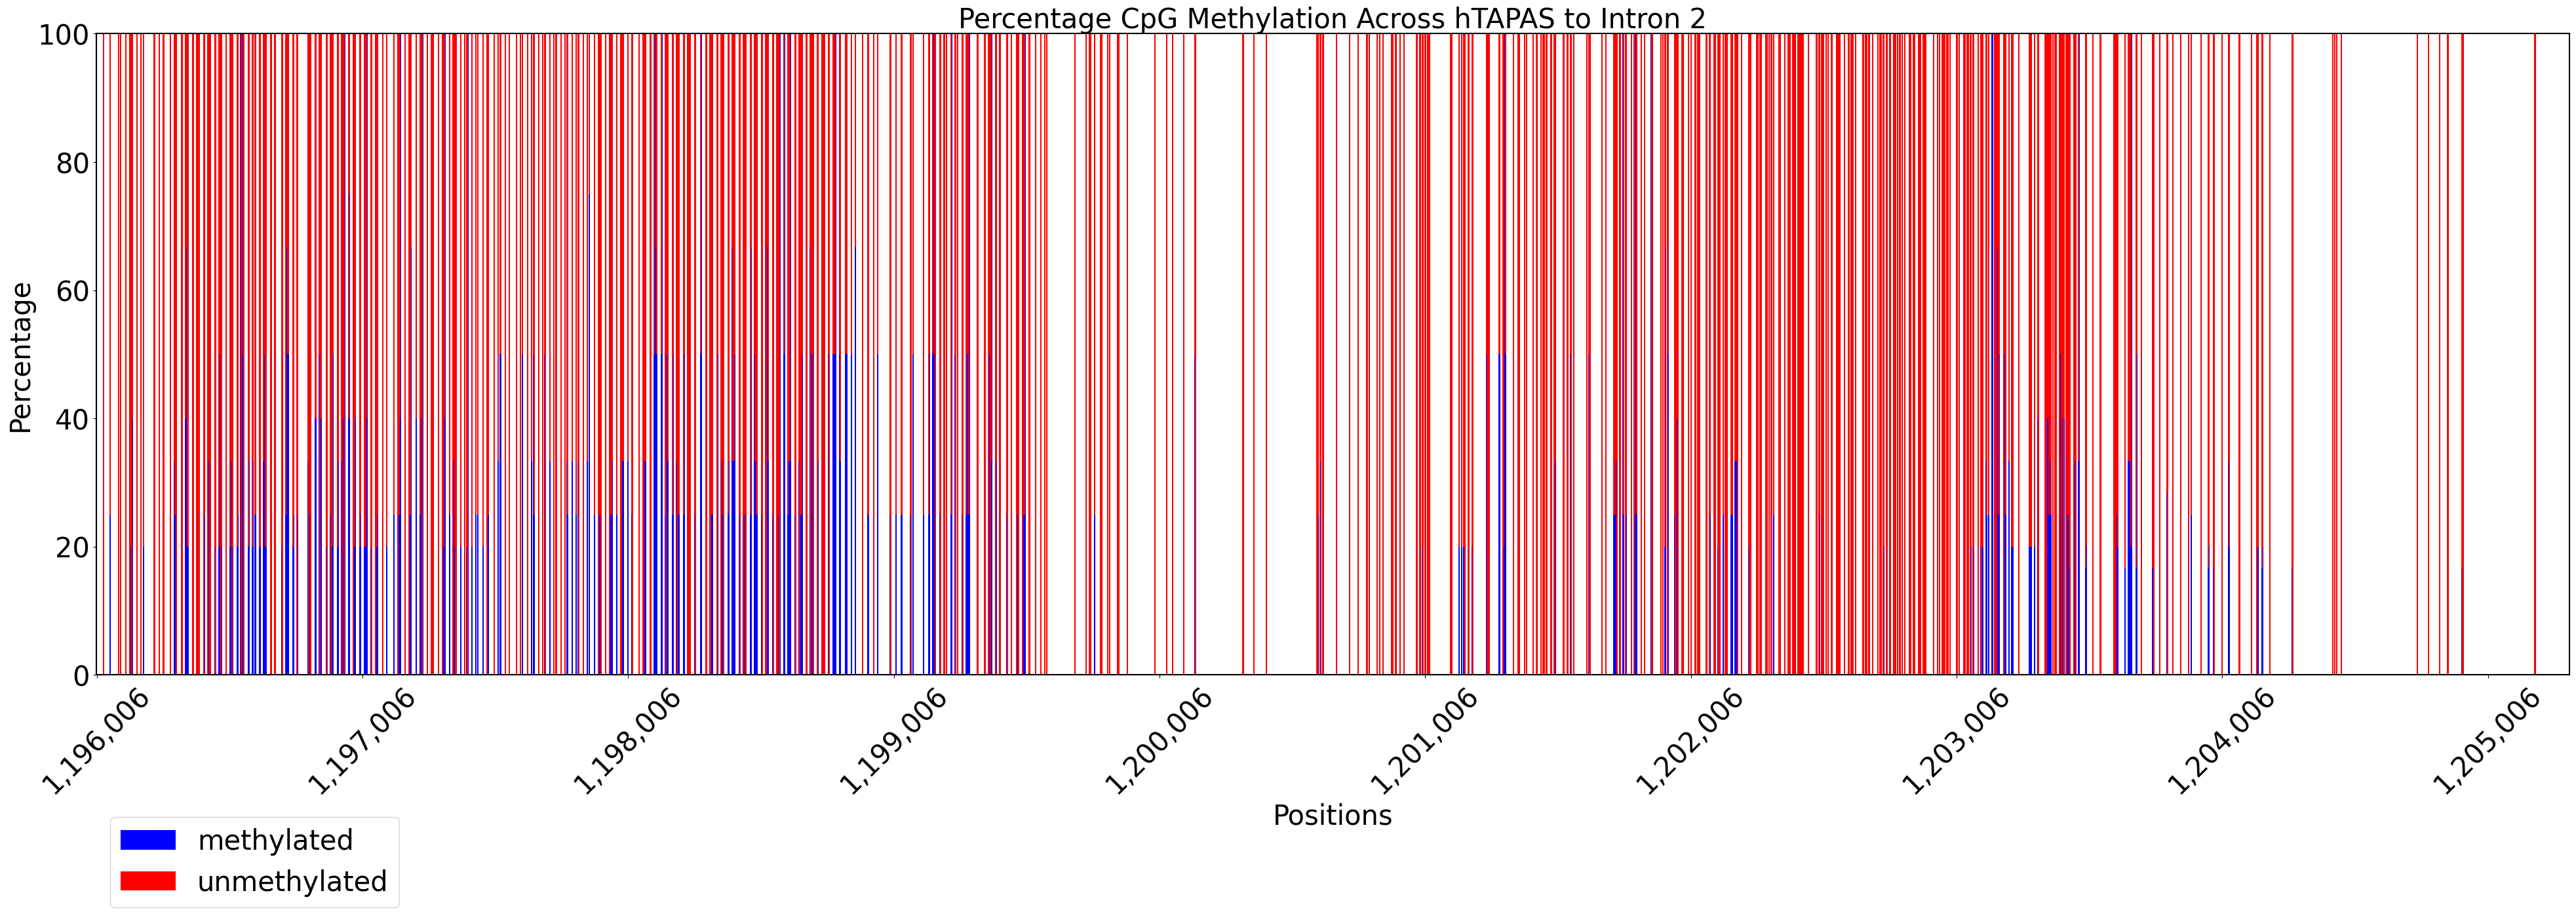

DORADO_DEMUX/6625ff67fb7d802182a83888398d8e73dbfd09d5_unclassified.bam.aligned.bam.sorted.bam.bed


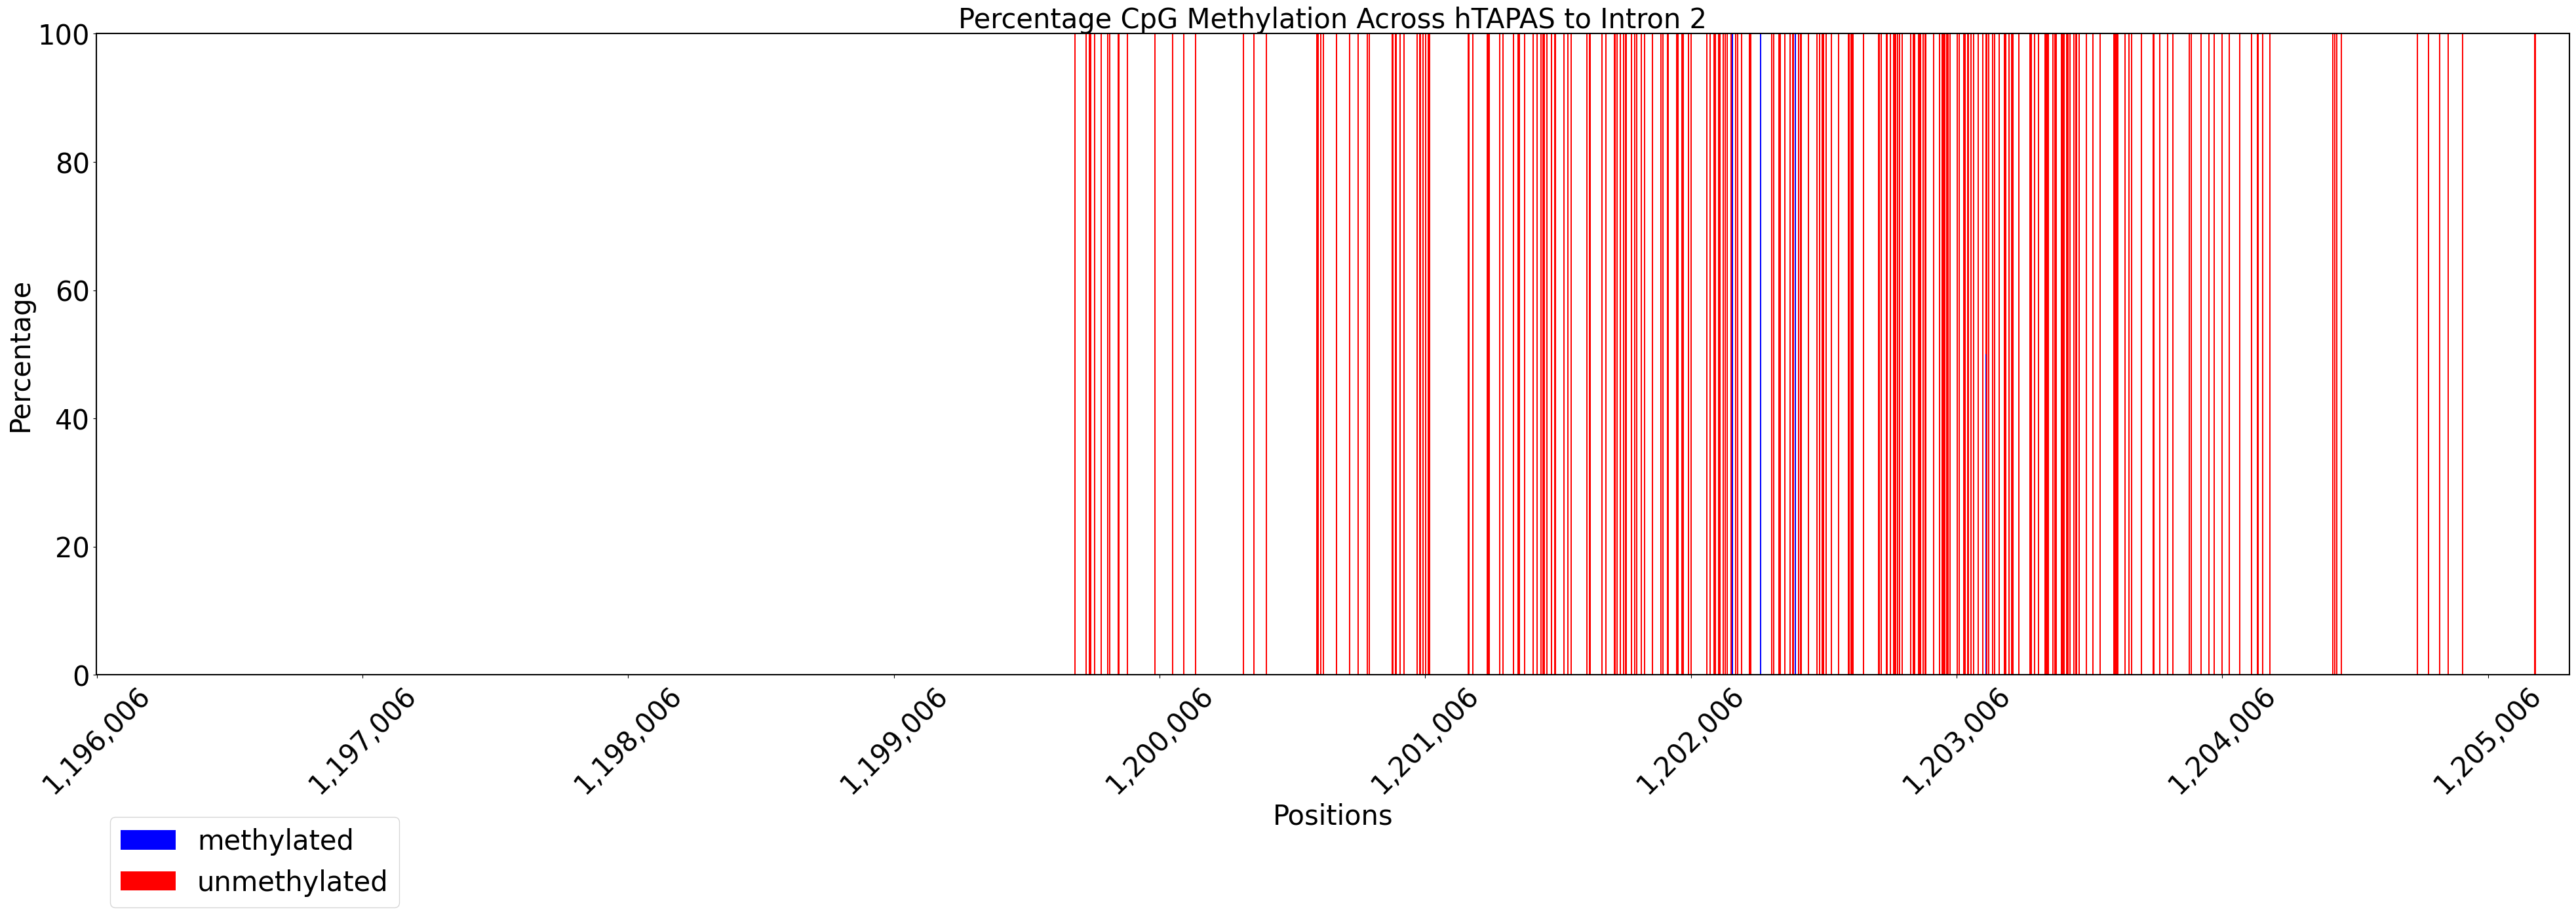

In [21]:
files = pd.read_csv("/media/data_01/vapatter/PROJECTS/15-LARS/137_LE_hTERT_CRISPR_HEK_Aza_cutsitetest/T2T/DORADO_DEMUX/files.txt", header = None)
files = list(files[0])
for f in files:
    TAPASmeth("DORADO_DEMUX/"+f)

## Annotation

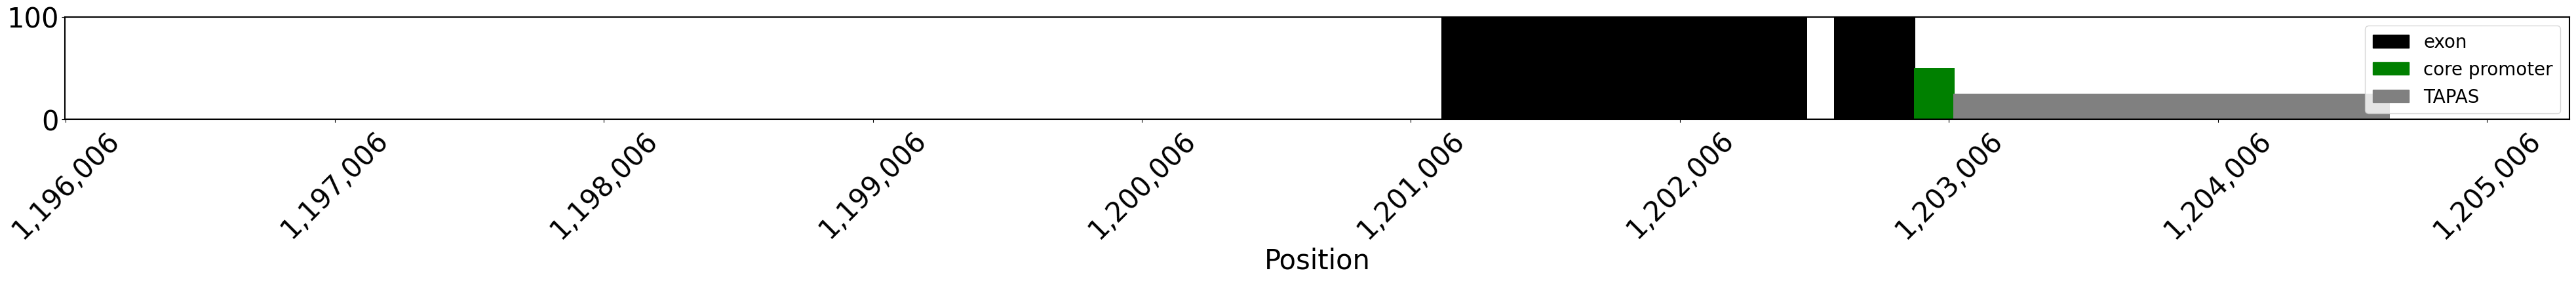

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as mpe
import matplotlib.patches as mpatches

# Initialize annot dictionary
file = open("/media/data_01/shared/GENOMES/homo_sapiens/T2T-CHM13v2.0/genome/loc2.fa", "r")
annot = {}
count = 1196005

for line in file:
    a = list(line)
    for i in a:
        count += 1
        annot[count] = 0
file.close()

# Define regions to color-code
for k, v in annot.items():
    if 1201123 <= k <= 1202476:
        annot[k] = 100
    elif 1202581 <= k <= 1202878:
        annot[k] = 100
    elif 1202862 <= k <= 1203024:
        annot[k] = 50
    elif 1203024 <= k <= 1204643:
        annot[k] = 25

# Set up the plot
fig = plt.gcf()
fig.set_size_inches(40, 5)
plt.rcParams.update({'font.size': 30})
outline = mpe.withStroke(linewidth=8, foreground='black')

# Extract x labels and y values
x_labels = list(annot.keys())
y1_values = [float(val) for val in annot.values()]
x = np.arange(len(x_labels))

# Define color map based on y1_values
colors = ['black' if y == 100 else 'green' if y == 50 else 'grey' if y == 25 else 'blue' for y in y1_values]

# Plot the bars with color coding
plt.bar(x, y1_values, color=colors, align='center', width=5)

# Add legend for color codes
black_patch = mpatches.Patch(color='black', label='exon')
green_patch = mpatches.Patch(color='green', label='core promoter')
grey_patch = mpatches.Patch(color='grey', label='TAPAS')
#blue_patch = mpatches.Patch(color='blue', label='Other')

plt.legend(handles=[black_patch, green_patch, grey_patch], fontsize=20, loc="upper right")

# Customize ticks and labels
tick_positions = np.arange(0, len(x_labels), 1000)
tick_labels = [f"{int(x_labels[i]):,}" for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, fontsize=30)
plt.xlabel("Position", fontsize=30)

# Add a border around the plot
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.margins(0)

# Save the figure
plt.savefig("/media/data_01/vapatter/PROJECTS/15-LARS/PDF/hTAPAStoIntron2Annotation.pdf", format="pdf", bbox_inches="tight")

# Show plot
plt.tight_layout()
plt.show()
